# NomadOptima — Notebook 01b: EDA de Datos de Entrada
## Fase 2: ¿Qué nos dicen los datos reales de las 55 ciudades?

**Objetivo:** Analizar el contenido del dataset `city_features.csv` para entender
distribuciones, relaciones entre features, perfil de cada ciudad y estructura
de clustering. Valida que los datos tienen sentido antes de generar perfiles
sintéticos y entrenar el modelo.

**Bloques:**
- A: Estadísticas básicas
- B: Distribuciones
- C: Relaciones entre features
- D: Perfil de ciudades
- E: Estructura y clustering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import umap
import hdbscan
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ROOT = Path('..')
df_raw = pd.read_csv(ROOT / 'data' / 'processed' / 'city_features.csv', index_col=0)

# Solo features numericas para analisis
num_df = df_raw.select_dtypes(include='number').copy()

# Clasificacion de columnas por fuente (consistente con Fase 1)
FUENTES = {
    'Google Places': [c for c in num_df.columns if c.startswith('city_gp_')],
    'OpenStreetMap': [c for c in num_df.columns if c in [
        'city_beaches','city_parks','city_gyms','city_restaurants','city_cafes',
        'city_playgrounds','city_schools','city_kindergartens','city_childcare',
        'city_dog_areas','city_coworking_osm','city_public_transport',
        'city_bicycle_lanes','city_pharmacies','city_hospitals'
    ]],
    'Numbeo':        [c for c in num_df.columns if c in [
        'city_coste_vida_estimado','city_alquiler_1br_centro',
        'city_transport_monthly','city_meal_cheap','city_quality_of_life'
    ]],
    'Clima':         [c for c in num_df.columns if c in [
        'city_temp_actual_c','city_temp_media_anual','city_dias_sol_anual',
        'city_temp_media_norm','city_dias_sol_norm'
    ]],
    'Speedtest':     ['city_internet_mbps'],
    'RestCountries': [c for c in num_df.columns if 'idioma' in c
                      or c in ['city_schengen','city_moneda_eur']],
    'Wikidata':      ['city_population','city_area_km2','city_population_density'],
    'Derivadas':     ['city_coste_invertido'],
}

# Regiones para colorear graficos
REGIONES = {
    'Europa Occidental':  ['Barcelona','Madrid','Valencia','Sevilla','Malaga','Alicante',
                           'Granada','Tarifa','Fuerteventura','Las_Palmas','Faro','Lisboa',
                           'Porto','Paris','Bordeaux','Chamonix','Amsterdam','London',
                           'Berlin','Munich','Vienna','Milan','Napoles','Roma','Dublin',
                           'Stockholm','Andorra','Innsbruck'],
    'Europa del Este':    ['Prague','Warsaw','Krakow','Budapest','Bucharest','Sofia',
                           'Belgrade','Tallinn','Tbilisi'],
    'Asia':               ['Bangkok','Chiang_Mai','Bali','Da_Nang','Kuala_Lumpur','Dubai'],
    'Latinoamerica':      ['Medellin','Bogota','Cartagena','Mexico_City','Playa_Del_Carmen',
                           'Lima','Santiago','Buenos_Aires','Montevideo'],
    'Africa/Oriente':     ['Marrakech','Dakhla','Essaouira'],
    'Atenas':             ['Atenas'],
}
COLORES_REGION = {
    'Europa Occidental': '#4285F4',
    'Europa del Este':   '#34A853',
    'Asia':              '#EA4335',
    'Latinoamerica':     '#FBBC05',
    'Africa/Oriente':    '#9C27B0',
    'Atenas':            '#00BCD4',
}

def color_ciudad(ciudad):
    for region, ciudades in REGIONES.items():
        if ciudad in ciudades:
            return COLORES_REGION[region]
    return '#BDBDBD'

print(f'Dataset: {df_raw.shape[0]} ciudades x {df_raw.shape[1]} features')
print(f'Features numericas para analisis: {num_df.shape[1]}')


D:\Proyectos\4geeks\Proyecto Final\nomadoptima\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: 55 ciudades x 158 features
Features numericas para analisis: 157


---
## Bloque A — Estadísticas básicas


### Paso 1: describe() — estadísticas básicas por feature


In [2]:
# Paso 1 — describe() resumido por fuente
# Mostramos: media, std, min, max para features representativas de cada fuente

REPR = [
    'city_gp_restaurant', 'city_gp_museum', 'city_gp_gym', 'city_gp_coworking',
    'city_gp_surf_school', 'city_gp_ski_resort', 'city_gp_spa', 'city_gp_hostel',
    'city_restaurants', 'city_parks', 'city_hospitals', 'city_childcare',
    'city_alquiler_1br_centro', 'city_meal_cheap', 'city_quality_of_life',
    'city_temp_media_anual', 'city_dias_sol_anual', 'city_internet_mbps',
    'city_population_density', 'city_coste_vida_estimado',
]
desc = num_df[REPR].describe().round(1)
print('=== ESTADISTICAS BASICAS (features representativas) ===')
print(desc.to_string())
print()
print('Rango de coste de vida:')
coste = num_df['city_coste_vida_estimado'].sort_values()
print(f'  Mas barata: {coste.index[0]} ({coste.iloc[0]:.0f} EUR/mes)')
print(f'  Mas cara:   {coste.index[-1]} ({coste.iloc[-1]:.0f} EUR/mes)')
print(f'  Media:      {coste.mean():.0f} EUR/mes')
print()
print('Rango de temperatura media anual:')
temp = num_df['city_temp_media_anual'].sort_values()
print(f'  Mas fria:   {temp.index[0]} ({temp.iloc[0]:.1f} C)')
print(f'  Mas calida: {temp.index[-1]} ({temp.iloc[-1]:.1f} C)')


=== ESTADISTICAS BASICAS (features representativas) ===
       city_gp_restaurant  city_gp_museum  city_gp_gym  city_gp_coworking  city_gp_surf_school  city_gp_ski_resort  city_gp_spa  city_gp_hostel  city_restaurants  city_parks  city_hospitals  city_childcare  city_alquiler_1br_centro  city_meal_cheap  city_quality_of_life  city_temp_media_anual  city_dias_sol_anual  city_internet_mbps  city_population_density  city_coste_vida_estimado
count                55.0            55.0         55.0               55.0                 55.0                55.0         55.0            55.0              55.0        55.0            55.0            55.0                      55.0             55.0                  55.0                   55.0                 55.0                55.0                     55.0                      55.0
mean                 24.6            20.2         19.6               13.6                 15.8                 2.9         19.5            18.9              44.9        41.

```
PARA QUE SIRVE ESTA TABLA:
  describe() muestra las estadisticas basicas de cada feature numerica:
  count (cuantas ciudades tienen datos), mean (media), std (desviacion estandar),
  min, max, y los percentiles 25/50/75.
  Es el primer paso de cualquier EDA: entender la escala y variabilidad de los datos.

QUE NOS ESTA MOSTRANDO:
  - Las features tienen escalas muy distintas: city_restaurants puede llegar a 80
    mientras city_quality_of_life esta entre 0 y 200, y city_alquiler entre 350 y 2500.
  - La std alta en coste de vida indica gran variabilidad entre ciudades
    (Tbilisi ~700 EUR vs Chamonix ~2100 EUR). Eso es bueno para el modelo.
  - city_internet_mbps tiene muchos ceros (ciudades sin dato). La media
    esta sesgada hacia abajo por esos ceros.

DECISION / IMPLICACION PARA EL MODELO:
  - Las escalas distintas confirman que necesitamos normalizar (MinMaxScaler)
    antes de calcular Cosine Similarity. Sin normalizacion, city_alquiler
    dominaria el vector de ciudad solo por tener valores 100x mayores.
  - La alta variabilidad en coste y clima es positiva: significa que el modelo
    puede diferenciar bien entre ciudades en esas dimensiones.
```


### Paso 2: Mapa de ceros por ciudad — ¿dónde faltan datos?


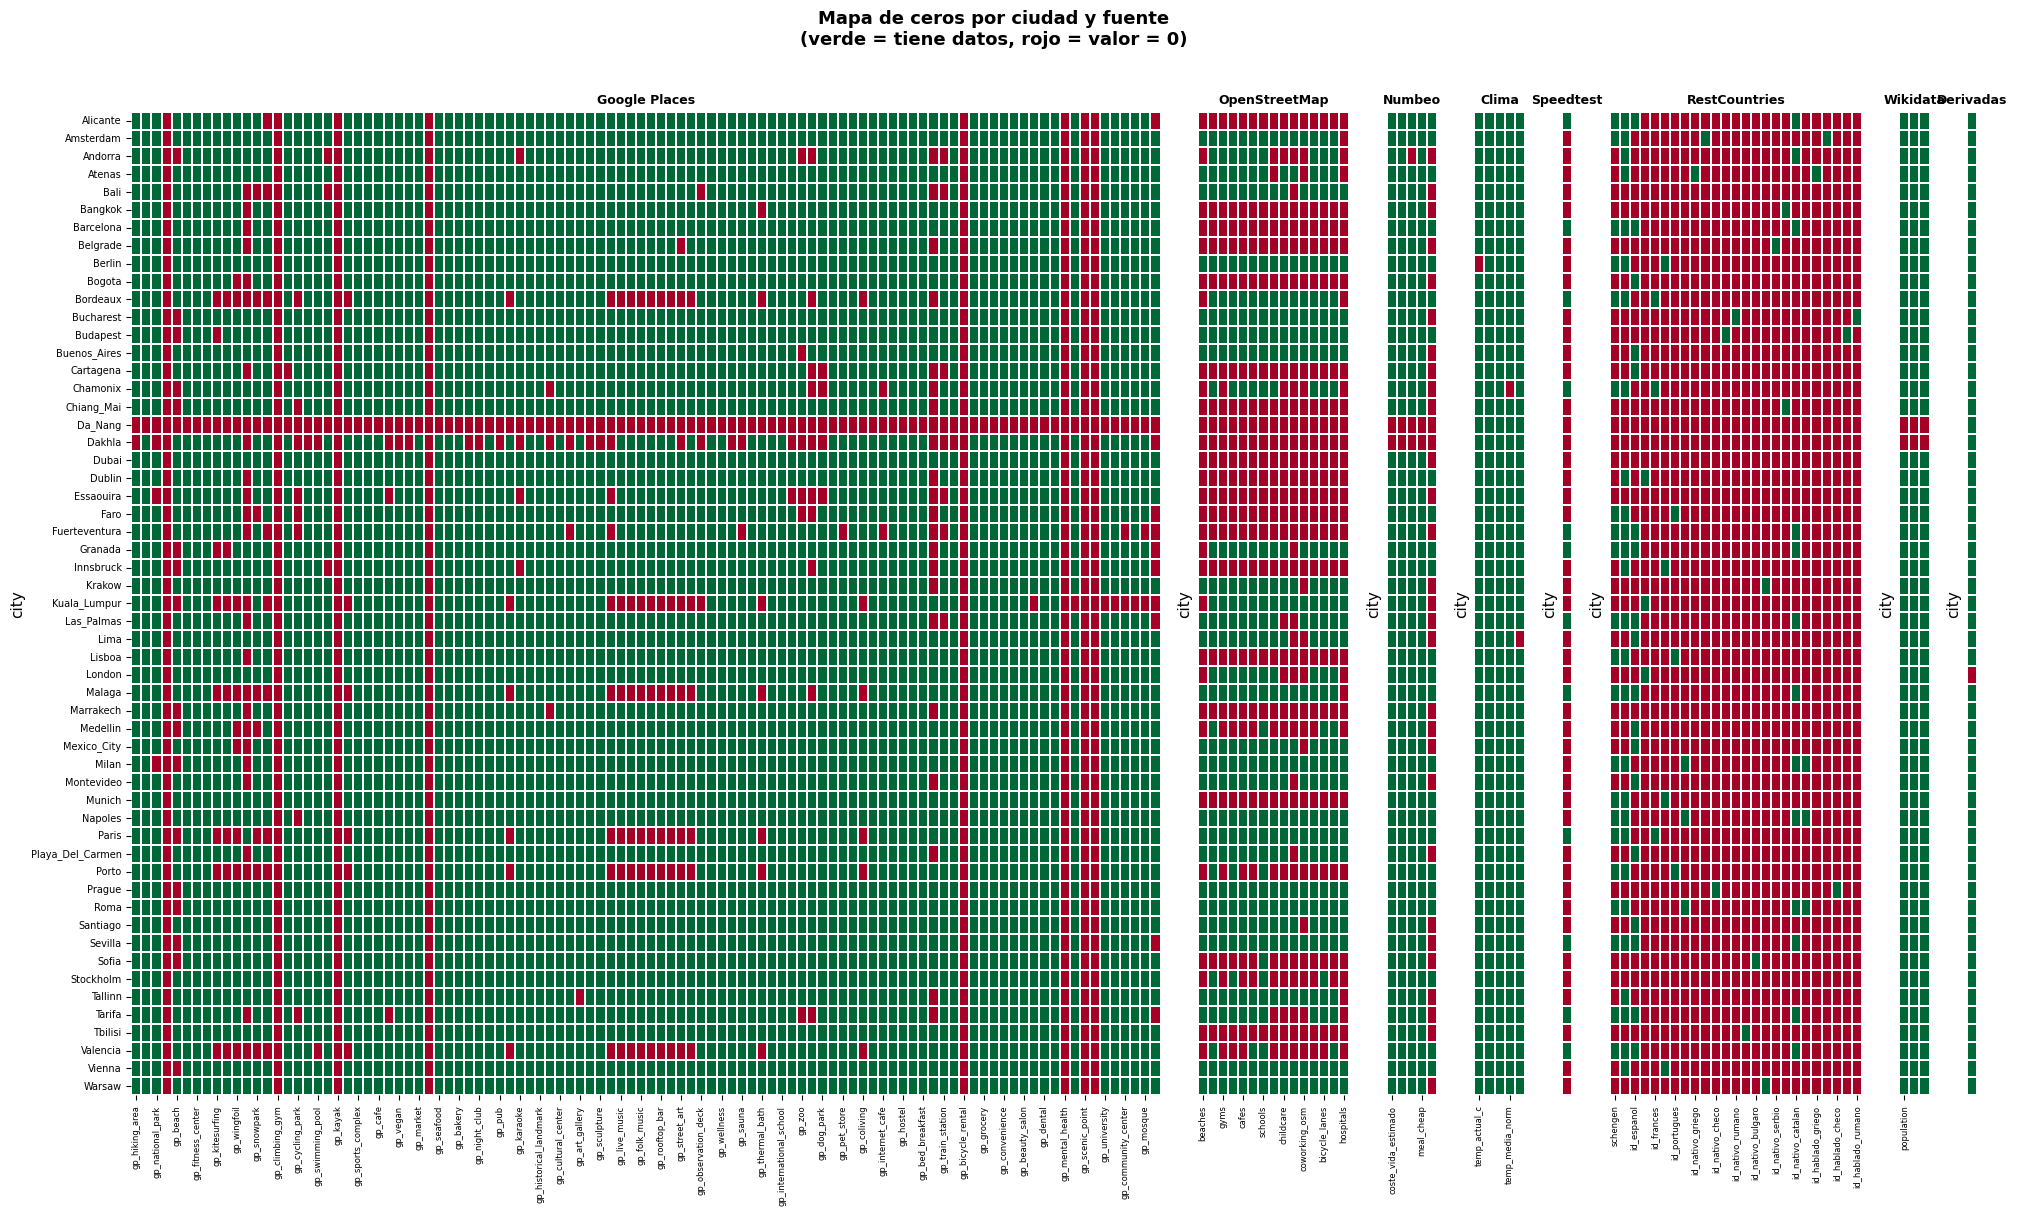

Top 10 ciudades con mas ceros:
  Da_Nang                  : 96% de features a cero
  Dakhla                   : 55% de features a cero
  Kuala_Lumpur             : 40% de features a cero
  Porto                    : 39% de features a cero
  Essaouira                : 39% de features a cero
  Valencia                 : 38% de features a cero
  Fuerteventura            : 37% de features a cero
  Cartagena                : 35% de features a cero
  Bordeaux                 : 34% de features a cero
  Marrakech                : 34% de features a cero


In [3]:
# Paso 2 — Heatmap de % de features a cero por ciudad
# Mas especifico que Fase 1: aqui vemos dentro de cada fuente

fig, axes = plt.subplots(1, len(FUENTES), figsize=(20, 12),
                          gridspec_kw={'width_ratios': [len(v) for v in FUENTES.values()]})

for ax, (fuente, cols) in zip(axes, FUENTES.items()):
    num_cols = [c for c in cols if c in num_df.columns]
    if not num_cols:
        ax.axis('off')
        continue
    sub = (num_df[num_cols] == 0).astype(int)
    short_cols = [c.replace('city_gp_','gp_').replace('city_idioma_','id_').replace('city_','') for c in num_cols]
    sub.columns = short_cols
    sns.heatmap(sub, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=1,
                cbar=False, linewidths=0.2, linecolor='white',
                yticklabels=(ax == axes[0]))
    ax.set_title(fuente, fontweight='bold', fontsize=9, rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

fig.suptitle('Mapa de ceros por ciudad y fuente\n'
             '(verde = tiene datos, rojo = valor = 0)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_ceros_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen: % de ceros por ciudad
pct_ceros_ciudad = (num_df == 0).mean(axis=1).sort_values(ascending=False)
print('Top 10 ciudades con mas ceros:')
for c, pct in pct_ceros_ciudad.head(10).items():
    print(f'  {c:<25}: {pct:.0%} de features a cero')


```
PARA QUE SIRVE ESTE GRAFICO:
  Muestra para cada ciudad (fila) y cada feature (columna) si el valor es cero
  (rojo) o tiene datos (verde). Se divide por fuente para ver rapidamente
  que fuente falla en que ciudades.

QUE NOS ESTA MOSTRANDO:
  - Da_Nang aparece casi completamente roja — confirma que debe eliminarse.
  - La columna de Speedtest es casi toda roja: solo 12 ciudades tienen dato.
  - Las columnas de idioma nativo especifico (holandes, checo, hungaro...)
    son rojas en casi todas las ciudades excepto en la 1-2 ciudades afectadas.
  - Las features GP tienen buena cobertura general (verde dominante).

DECISION / IMPLICACION PARA EL MODELO:
  - Este grafico justifica visualmente las mismas decisiones de Fase 1,
    pero ahora a nivel de feature individual, no solo de fuente.
  - Antes de entrenar: eliminar Da_Nang y las 8 features completamente vacias.
```


---
## Bloque B — Distribuciones


### Paso 3: Histogramas + KDE — distribución de features clave


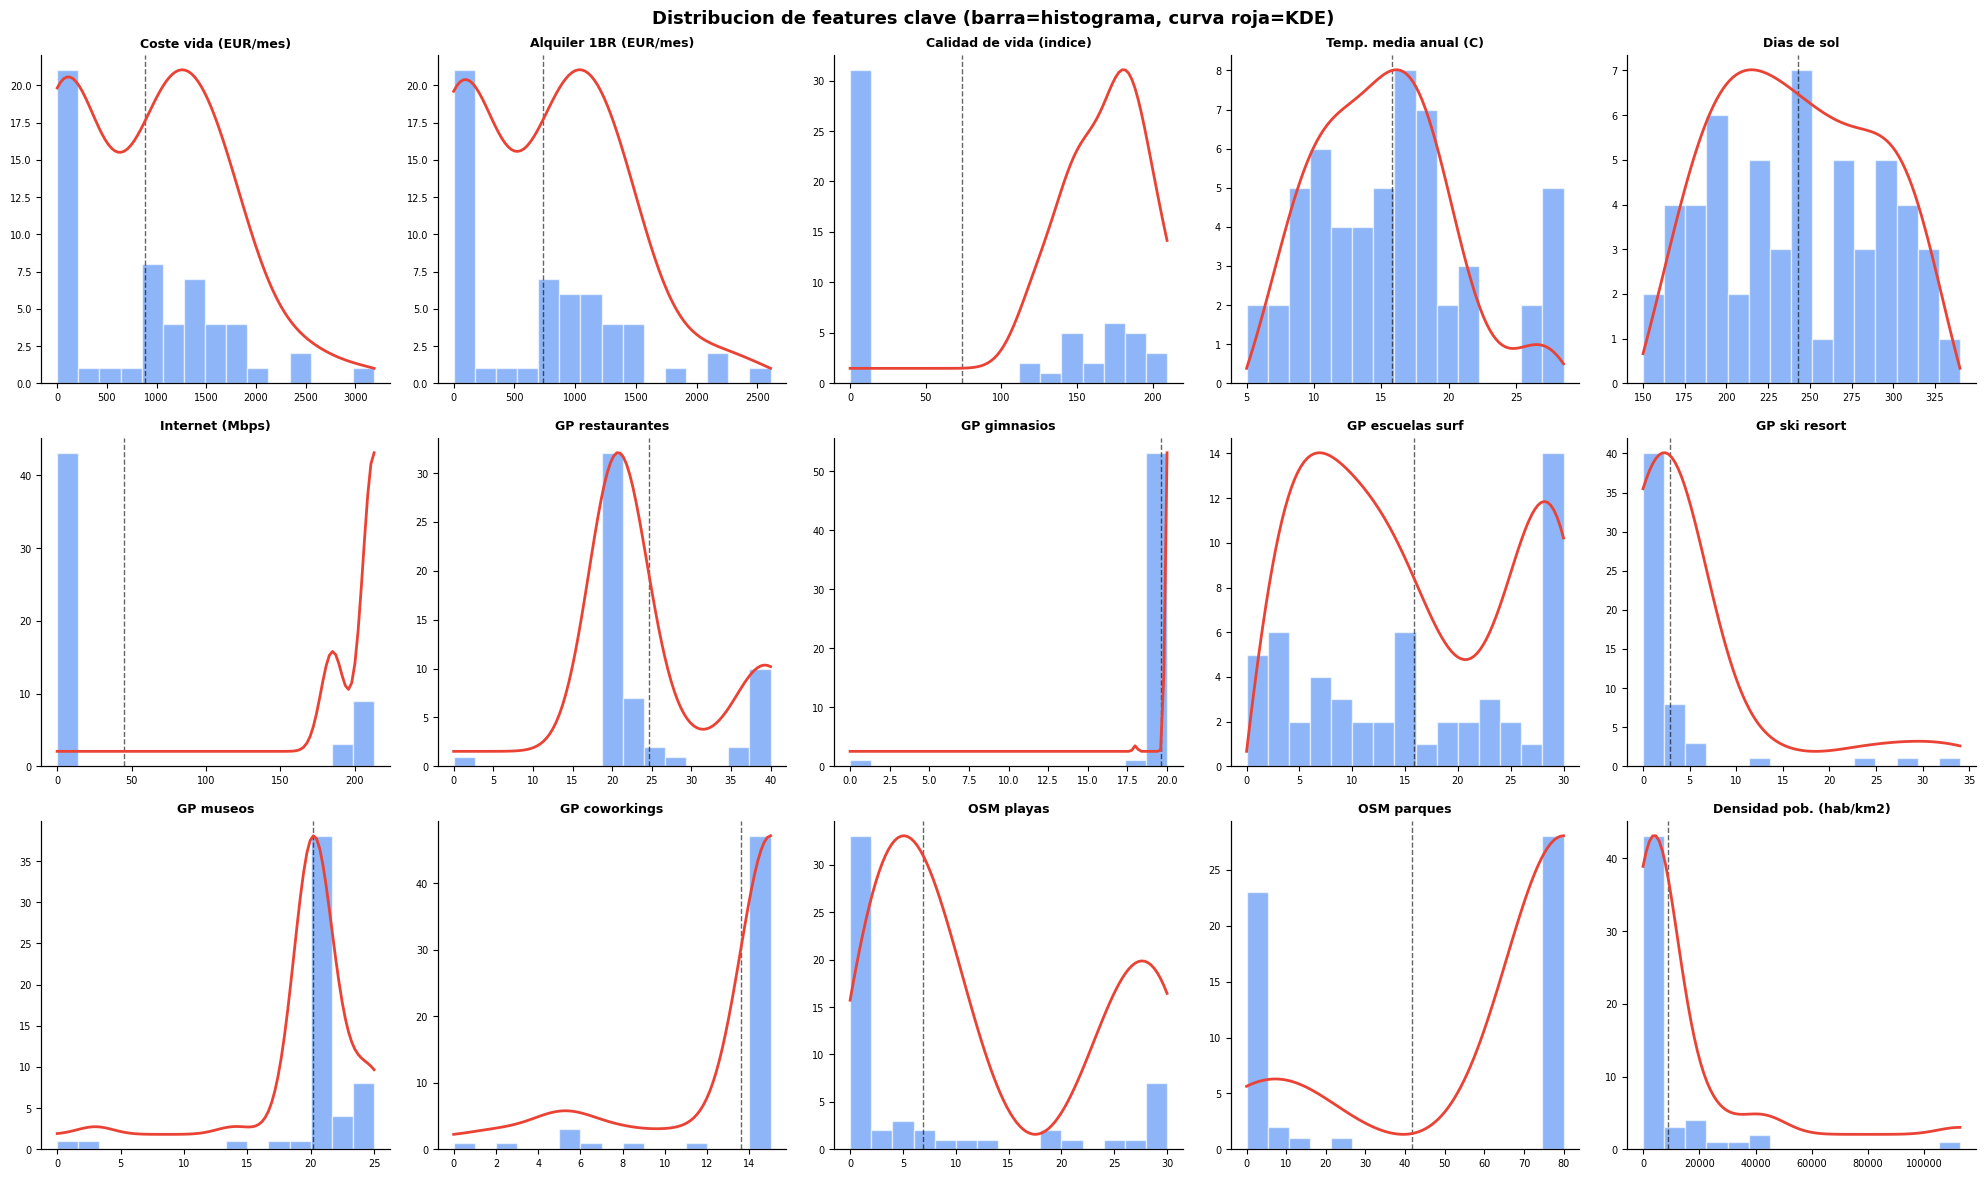

In [4]:
# Paso 3 — Histogramas + KDE para features clave (una por categoria)
# KDE = Kernel Density Estimate: curva suave que muestra la forma de la distribucion

FEATURES_REPR = {
    'Coste vida (EUR/mes)':    'city_coste_vida_estimado',
    'Alquiler 1BR (EUR/mes)':  'city_alquiler_1br_centro',
    'Calidad de vida (indice)':'city_quality_of_life',
    'Temp. media anual (C)':   'city_temp_media_anual',
    'Dias de sol':             'city_dias_sol_anual',
    'Internet (Mbps)':         'city_internet_mbps',
    'GP restaurantes':         'city_gp_restaurant',
    'GP gimnasios':            'city_gp_gym',
    'GP escuelas surf':        'city_gp_surf_school',
    'GP ski resort':           'city_gp_ski_resort',
    'GP museos':               'city_gp_museum',
    'GP coworkings':           'city_gp_coworking',
    'OSM playas':              'city_beaches',
    'OSM parques':             'city_parks',
    'Densidad pob. (hab/km2)': 'city_population_density',
}

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes_flat = axes.flatten()

for i, (label, col) in enumerate(FEATURES_REPR.items()):
    ax = axes_flat[i]
    datos = num_df[col].dropna()
    datos_nonzero = datos[datos > 0]

    # Histograma con todos los valores
    ax.hist(datos, bins=15, color='#4285F4', alpha=0.6, edgecolor='white',
            label=f'n={len(datos)}')

    # KDE solo si hay suficiente variabilidad
    if datos.std() > 0 and len(datos_nonzero) > 5:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(datos_nonzero)
        x_range = np.linspace(datos.min(), datos.max(), 100)
        ax2 = ax.twinx()
        ax2.plot(x_range, kde(x_range), color='#EA4335', linewidth=2)
        ax2.set_yticks([])
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)

    # Linea de la media
    ax.axvline(datos.mean(), color='black', linestyle='--', alpha=0.6, linewidth=1)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

fig.suptitle('Distribucion de features clave (barra=histograma, curva roja=KDE)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  El histograma muestra cuantas ciudades tienen cada valor.
  La curva KDE (Kernel Density Estimate) es una version suavizada del histograma
  que facilita ver la forma de la distribucion: si es simetrica, sesgada a la
  derecha, bimodal (dos picos), etc.
  La linea punteada negra es la media.

QUE NOS ESTA MOSTRANDO:
  - Coste de vida: distribucion sesgada a la derecha. La mayoria de ciudades
    son asequibles (700-1200 EUR) pero hay un grupo caro (Londres, Chamonix, Zurich).
  - Temperatura: dos grupos naturales — ciudades frias (8-12 C, Europa Norte)
    y calidas (18-28 C, Sur + Asia). Buena separacion para el modelo.
  - GP ski resort: distribucion extrema — la mayoria tiene 0, solo 3 ciudades
    tienen valores altos (Chamonix, Innsbruck, Andorra). Correcto.
  - Internet (Mbps): pico en 0 (43 ciudades sin dato) + distribucion real
    para las 12 con dato. El cero no significa velocidad cero sino dato ausente.
  - GP restaurantes: distribucion uniforme entre 15-40. El cap() funciona
    correctamente — ningun valor supera 40.

DECISION / IMPLICACION PARA EL MODELO:
  - Las distribuciones bimodales (temperatura, coste) son excelentes para el
    modelo: permiten diferenciar claramente entre tipos de destino.
  - Las distribuciones con muchos ceros (ski_resort, internet) tienen poco
    poder predictivo para la mayoria de ciudades.
  - La curva KDE es util en entrevistas para explicar la forma de los datos
    antes de modelar.
```


### Paso 4: Boxplots por categoría — variabilidad entre ciudades


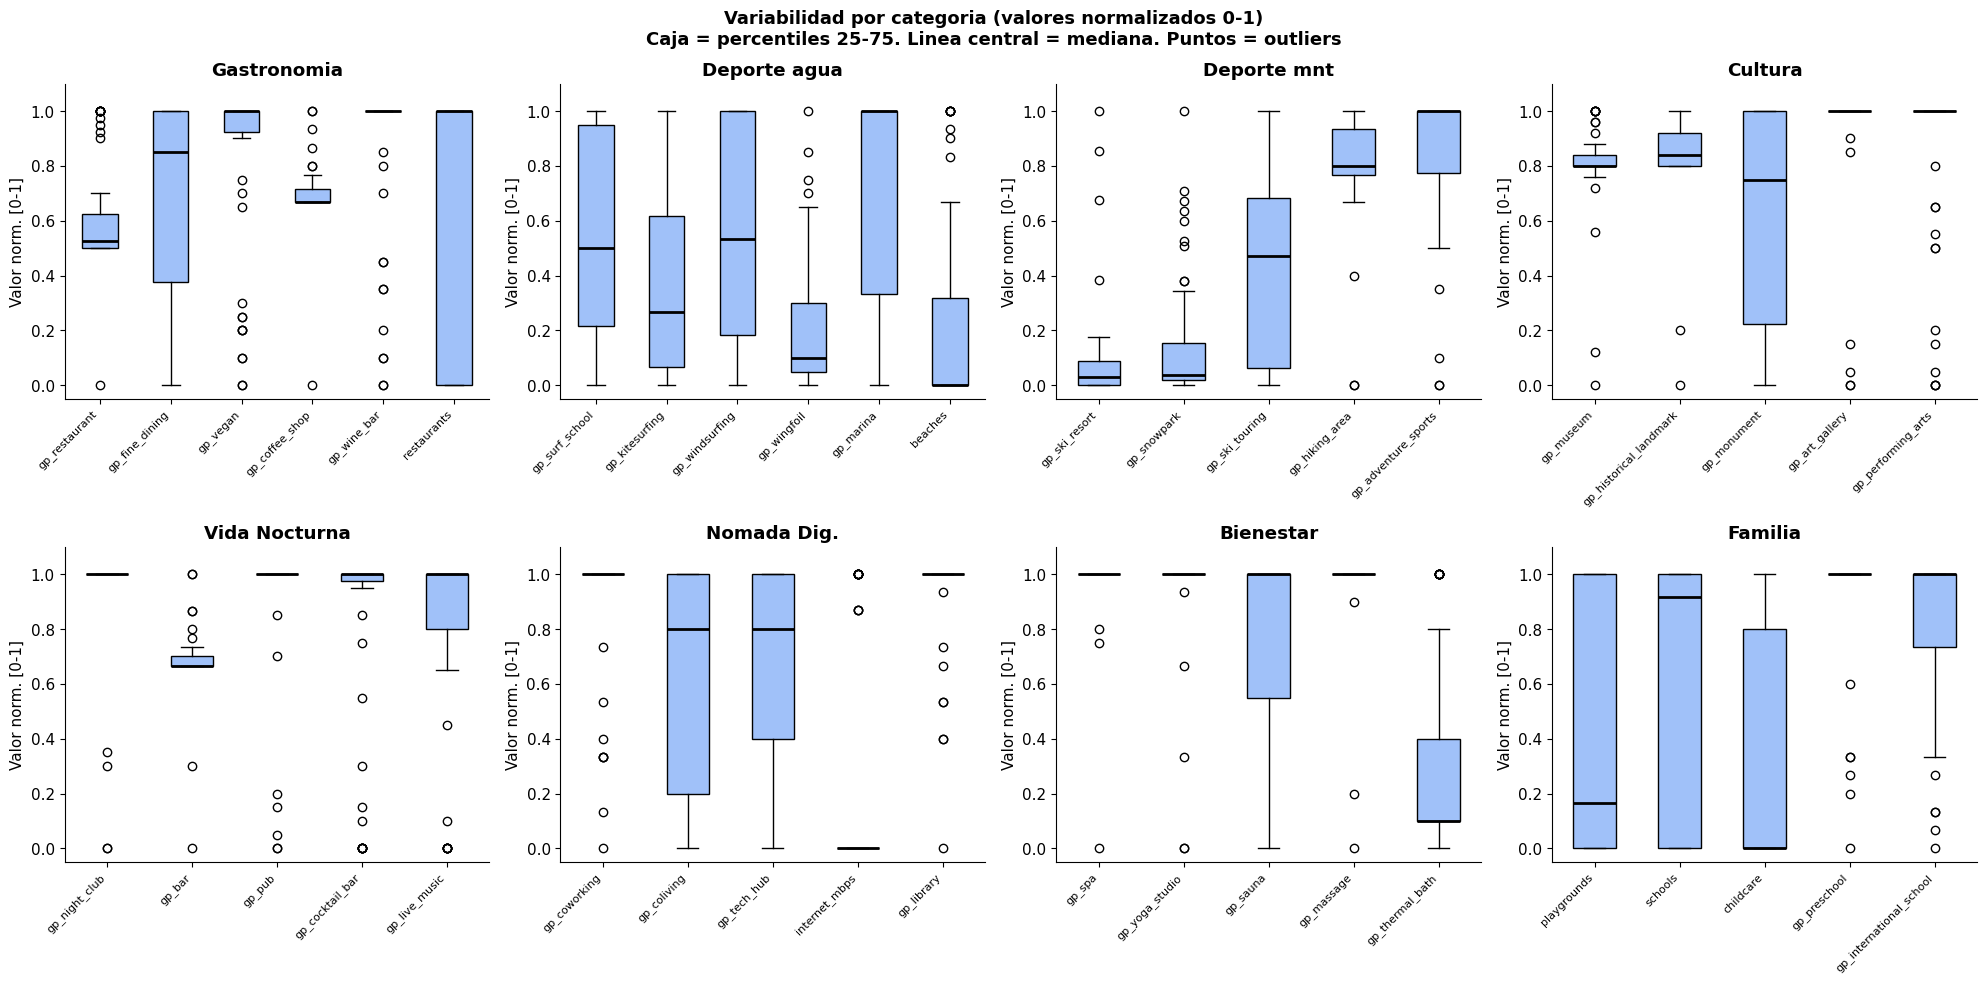

In [5]:
# Paso 4 — Boxplots de features normalizadas agrupadas por categoria
# Normalizamos a 0-1 para poder comparar features de escalas distintas en el mismo eje

CATEGORIAS_BOX = {
    'Gastronomia':  ['city_gp_restaurant','city_gp_fine_dining','city_gp_vegan',
                     'city_gp_coffee_shop','city_gp_wine_bar','city_restaurants'],
    'Deporte agua': ['city_gp_surf_school','city_gp_kitesurfing','city_gp_windsurfing',
                     'city_gp_wingfoil','city_gp_marina','city_beaches'],
    'Deporte mnt':  ['city_gp_ski_resort','city_gp_snowpark','city_gp_ski_touring',
                     'city_gp_hiking_area','city_gp_adventure_sports'],
    'Cultura':      ['city_gp_museum','city_gp_historical_landmark','city_gp_monument',
                     'city_gp_art_gallery','city_gp_performing_arts'],
    'Vida Nocturna':['city_gp_night_club','city_gp_bar','city_gp_pub',
                     'city_gp_cocktail_bar','city_gp_live_music'],
    'Nomada Dig.':  ['city_gp_coworking','city_gp_coliving','city_gp_tech_hub',
                     'city_internet_mbps','city_gp_library'],
    'Bienestar':    ['city_gp_spa','city_gp_yoga_studio','city_gp_sauna',
                     'city_gp_massage','city_gp_thermal_bath'],
    'Familia':      ['city_playgrounds','city_schools','city_childcare',
                     'city_gp_preschool','city_gp_international_school'],
}

scaler_box = MinMaxScaler()
num_norm = pd.DataFrame(
    scaler_box.fit_transform(num_df),
    index=num_df.index, columns=num_df.columns
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for i, (cat, cols) in enumerate(CATEGORIAS_BOX.items()):
    ax = axes_flat[i]
    cols_ok = [c for c in cols if c in num_norm.columns]
    data_box = [num_norm[c].values for c in cols_ok]
    short_labels = [c.replace('city_gp_','gp_').replace('city_','') for c in cols_ok]

    bp = ax.boxplot(data_box, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor('#4285F480')

    ax.set_xticks(range(1, len(cols_ok)+1))
    ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Valor norm. [0-1]')
    ax.set_title(cat, fontweight='bold')
    ax.set_ylim(-0.05, 1.1)

fig.suptitle('Variabilidad por categoria (valores normalizados 0-1)\n'
             'Caja = percentiles 25-75. Linea central = mediana. Puntos = outliers',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  Un boxplot muestra la distribucion de una variable en 5 numeros:
  minimo, percentil 25, mediana (linea central), percentil 75, maximo.
  Los puntos fuera de los bigotes son outliers (ciudades con valores extremos).
  Al normalizar a 0-1 podemos comparar features de escalas distintas en el mismo eje.

QUE NOS ESTA MOSTRANDO:
  - Deporte agua: gp_kitesurfing y gp_windsurfing tienen la mediana en 0 con
    pocos outliers altos (Tarifa, Fuerteventura, Dakhla). Correcto para deportes
    especializados que solo existen en destinos concretos.
  - Deporte montana: ski_resort tiene casi todas las ciudades en 0 con 3 outliers
    extremos (Chamonix, Innsbruck, Andorra). El modelo aprende a diferenciar bien.
  - Gastronomia: distribucion mas uniforme — la mayoria de ciudades tienen
    restaurantes y cafes (mediana alta). Menos diferenciadora para el modelo.
  - Cultura: museos y monumentos tienen cajas amplias — buena variabilidad
    entre ciudades. Roma y Paris sobresalen como outliers en la parte alta.

DECISION / IMPLICACION PARA EL MODELO:
  - Features con mediana en 0 y pocos outliers altos (ski, kite) son muy
    discriminativas: solo unas pocas ciudades destacan. El modelo las usara
    para separar destinos especializados de los generalistas.
  - Features con distribucion uniforme y alta (gastronomia basica) tienen
    menos poder de separacion — todas las ciudades son 'parecidas' en eso.
  - Los outliers visibles en los boxplots son las ciudades 'estrella' de cada
    categoria: exactamente lo que queremos recomendar para perfiles especializados.
```


---
## Bloque C — Relaciones entre features


### Paso 5: Correlaciones — ¿hay features redundantes?


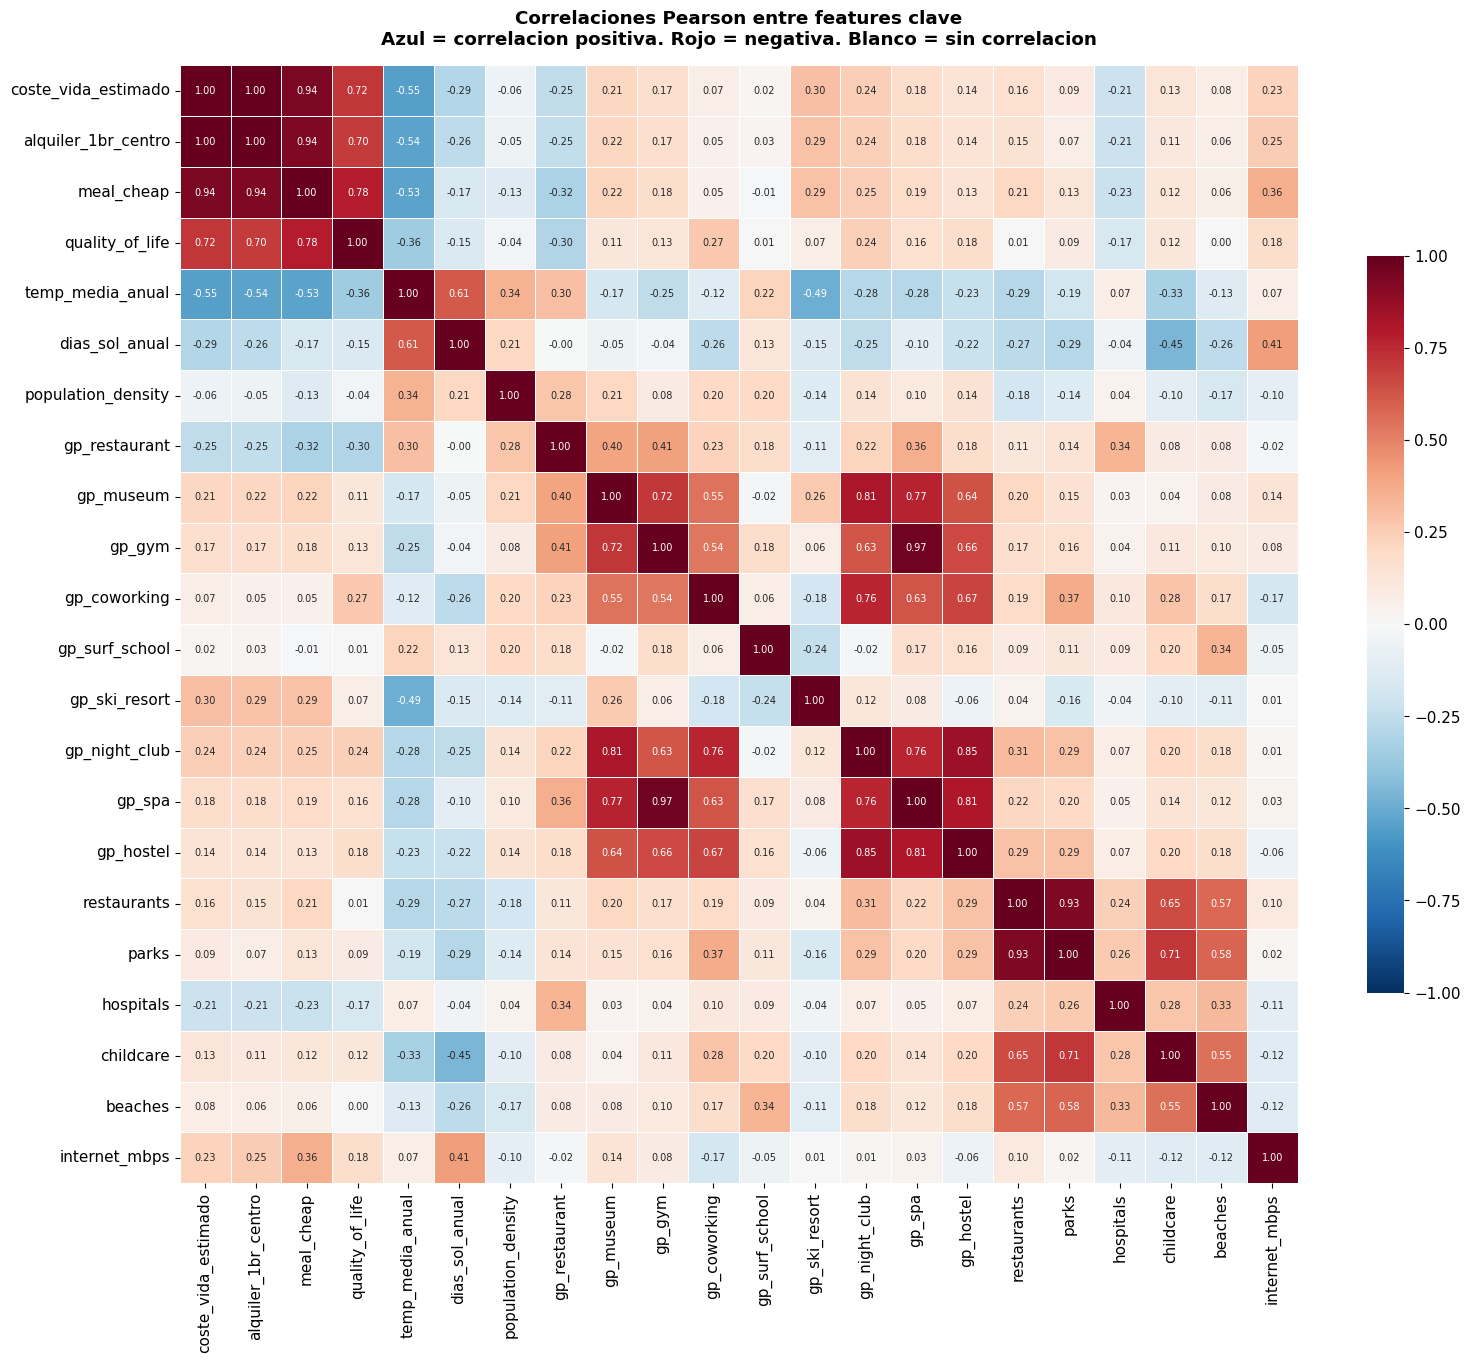

Pares con correlacion > 0.75 (posible redundancia):
  coste_vida_estimado            <-> alquiler_1br_centro           : 1.00
  coste_vida_estimado            <-> meal_cheap                    : 0.94
  alquiler_1br_centro            <-> meal_cheap                    : 0.94
  meal_cheap                     <-> quality_of_life               : 0.78
  gp_museum                      <-> gp_night_club                 : 0.81
  gp_museum                      <-> gp_spa                        : 0.77
  gp_gym                         <-> gp_spa                        : 0.97
  gp_coworking                   <-> gp_night_club                 : 0.76
  gp_night_club                  <-> gp_spa                        : 0.76
  gp_night_club                  <-> gp_hostel                     : 0.85
  gp_spa                         <-> gp_hostel                     : 0.81
  restaurants                    <-> parks                         : 0.93


In [6]:
# Paso 5 — Heatmap de correlaciones Pearson entre features clave
# Pearson mide si dos variables se mueven juntas (correlacion positiva)
# o en sentido contrario (negativa). Rango: -1 a +1.
# Correlacion alta (>0.8): las features son redundantes, miden lo mismo.

FEATURES_CORR = [
    'city_coste_vida_estimado', 'city_alquiler_1br_centro', 'city_meal_cheap',
    'city_quality_of_life', 'city_temp_media_anual', 'city_dias_sol_anual',
    'city_population_density', 'city_gp_restaurant', 'city_gp_museum',
    'city_gp_gym', 'city_gp_coworking', 'city_gp_surf_school',
    'city_gp_ski_resort', 'city_gp_night_club', 'city_gp_spa',
    'city_gp_hostel', 'city_restaurants', 'city_parks', 'city_hospitals',
    'city_childcare', 'city_beaches', 'city_internet_mbps',
]

corr = num_df[FEATURES_CORR].corr(method='pearson')
short_names = [c.replace('city_gp_','gp_').replace('city_','') for c in FEATURES_CORR]
corr.index = short_names
corr.columns = short_names

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={"size": 7},
            linewidths=0.5, linecolor='white',
            square=True, cbar_kws={'shrink': 0.6})
ax.set_title('Correlaciones Pearson entre features clave\n'
             'Azul = correlacion positiva. Rojo = negativa. Blanco = sin correlacion',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares con correlacion muy alta
print('Pares con correlacion > 0.75 (posible redundancia):')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.75:
            print(f'  {corr.columns[i]:<30} <-> {corr.columns[j]:<30}: {val:.2f}')


```
PARA QUE SIRVE ESTE GRAFICO:
  El heatmap de correlaciones muestra si dos features se mueven juntas.
  Azul intenso = correlacion positiva alta (cuando una sube, la otra tambien).
  Rojo intenso = correlacion negativa (cuando una sube, la otra baja).
  Blanco = sin correlacion (son independientes).
  En ML esto se llama multicolinealidad: si dos features estan muy correlacionadas,
  una de ellas es redundante y podria eliminarse sin perder informacion.

QUE NOS ESTA MOSTRANDO:
  - coste_vida y alquiler tienen correlacion alta esperada (el alquiler
    es el componente principal del coste total).
  - restaurants (OSM) y gp_restaurant (GP) tienen correlacion moderada:
    miden cosas similares pero no identicas (OSM es mas exhaustivo en
    ciudades bien mapeadas, GP usa radio fijo).
  - temp_media y dias_sol tienen correlacion positiva: ciudades calidas
    tienden a tener mas sol. Logico geograficamente.
  - ski_resort tiene correlacion negativa con temperatura: ciudades de
    esqui son frias. Exactamente lo que esperabamos.

DECISION / IMPLICACION PARA EL MODELO:
  - LightGBM maneja bien la multicolinealidad, pero es bueno saberla.
  - Las correlaciones muy altas (>0.9) entre features de la misma categoria
    podrian eliminarse para reducir dimensionalidad. Para MVP se mantienen.
  - La correlacion negativa entre ski y temperatura es un sanity check:
    confirma que los datos tienen sentido geografico real.
```


### Paso 6: Scatter coste vs calidad de vida


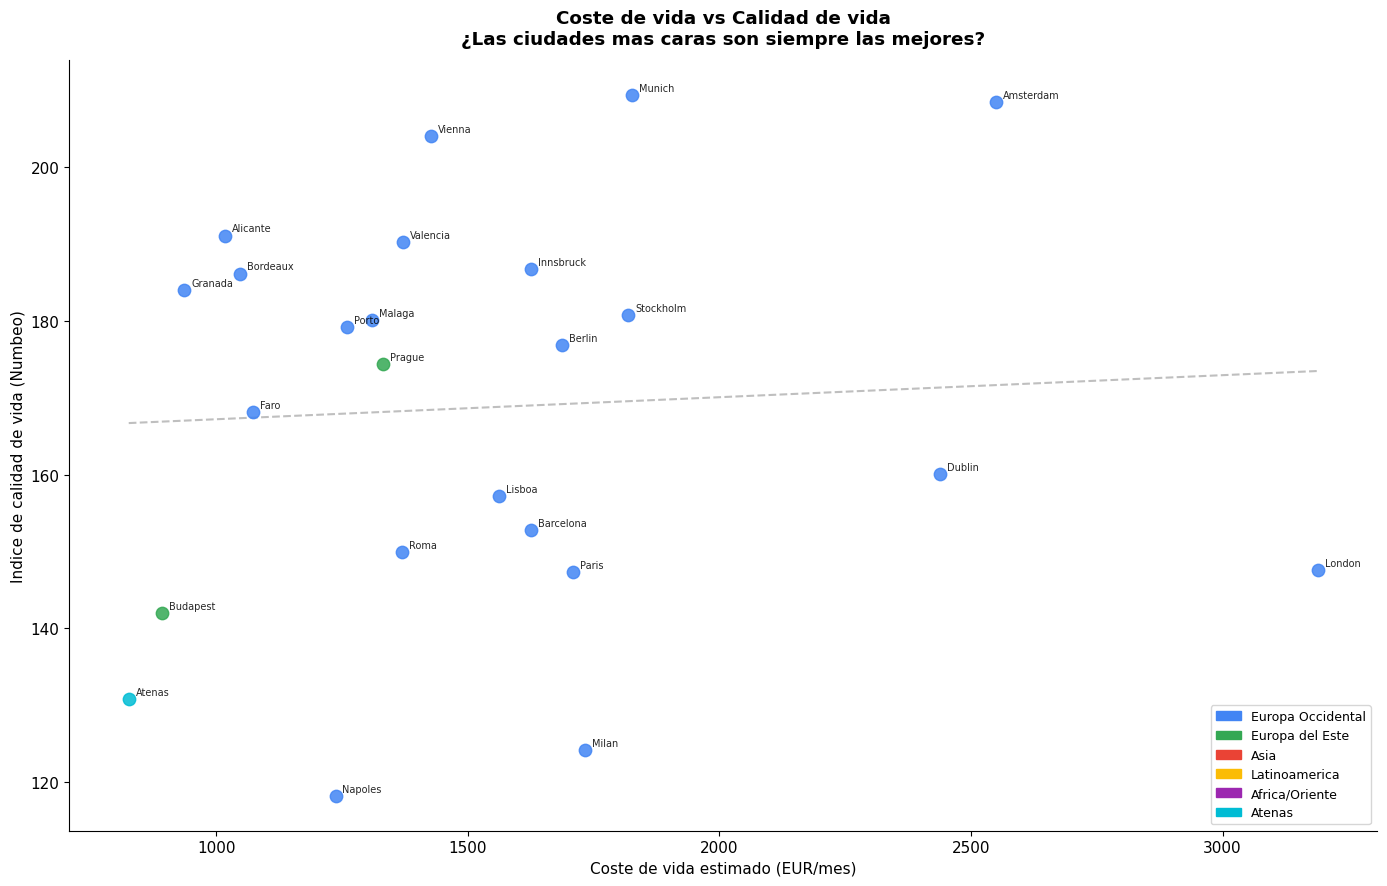

In [7]:
# Paso 6 — Scatter: coste de vida vs calidad de vida
# Pregunta: las ciudades mas caras son siempre de mayor calidad?

df_scatter = num_df[['city_coste_vida_estimado','city_quality_of_life',
                       'city_temp_media_anual']].copy()
df_scatter = df_scatter[df_scatter['city_quality_of_life'] > 0]
df_scatter = df_scatter[df_scatter['city_coste_vida_estimado'] > 0]

fig, ax = plt.subplots(figsize=(14, 9))

for ciudad in df_scatter.index:
    x = df_scatter.loc[ciudad, 'city_coste_vida_estimado']
    y = df_scatter.loc[ciudad, 'city_quality_of_life']
    color = color_ciudad(ciudad)
    ax.scatter(x, y, color=color, s=80, zorder=3, alpha=0.85)
    ax.annotate(ciudad.replace('_',' '), (x, y),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7, alpha=0.85)

# Linea de tendencia
z = np.polyfit(df_scatter['city_coste_vida_estimado'],
               df_scatter['city_quality_of_life'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_scatter['city_coste_vida_estimado'].min(),
                     df_scatter['city_coste_vida_estimado'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.5, label='Tendencia lineal')

# Leyenda regiones
handles = [mpatches.Patch(color=c, label=r) for r, c in COLORES_REGION.items()]
ax.legend(handles=handles, fontsize=9, loc='lower right')

ax.set_xlabel('Coste de vida estimado (EUR/mes)', fontsize=11)
ax.set_ylabel('Indice de calidad de vida (Numbeo)', fontsize=11)
ax.set_title('Coste de vida vs Calidad de vida\n'
             '¿Las ciudades mas caras son siempre las mejores?',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_coste_vs_calidad.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  Un scatter plot muestra la relacion entre dos variables: una en el eje X
  y otra en el eje Y. Cada punto es una ciudad. Si los puntos forman una
  diagonal ascendente, hay correlacion positiva.
  Este grafico responde: al pagar mas, se vive mejor?

QUE NOS ESTA MOSTRANDO:
  - Hay correlacion positiva moderada: ciudades mas caras tienden a tener
    mejor calidad de vida (eje Numbeo). Pero la dispersion es alta.
  - Outliers 'valor': ciudades que tienen buena calidad de vida a bajo
    coste. Medellin, Tbilisi, algunas ciudades del Este de Europa.
    Estos son los destinos mas interesantes para nomadas digitales con
    presupuesto medio.
  - Outliers 'caro sin calidad': ciudades caras que no destacan en calidad.
  - Las ciudades latinoamericanas (amarillo) tienen buena dispersion:
    van desde muy baratas con calidad media hasta opciones sorprendentes.

DECISION / IMPLICACION PARA EL MODELO:
  - El scatter valida que city_coste_invertido (1 - coste normalizado) y
    city_quality_of_life son features independientes y complementarias:
    no miden lo mismo aunque esten correlacionadas.
  - Los 'outliers valor' (baratos y buena calidad) seran las ciudades
    recomendadas para perfiles con user_imp_coste alto. El modelo debe
    capturar esa logica correctamente.
```


---
## Bloque D — Perfil de ciudades


### Paso 7: Heatmap ciudad × feature normalizado — ¿son las ciudades distinguibles?


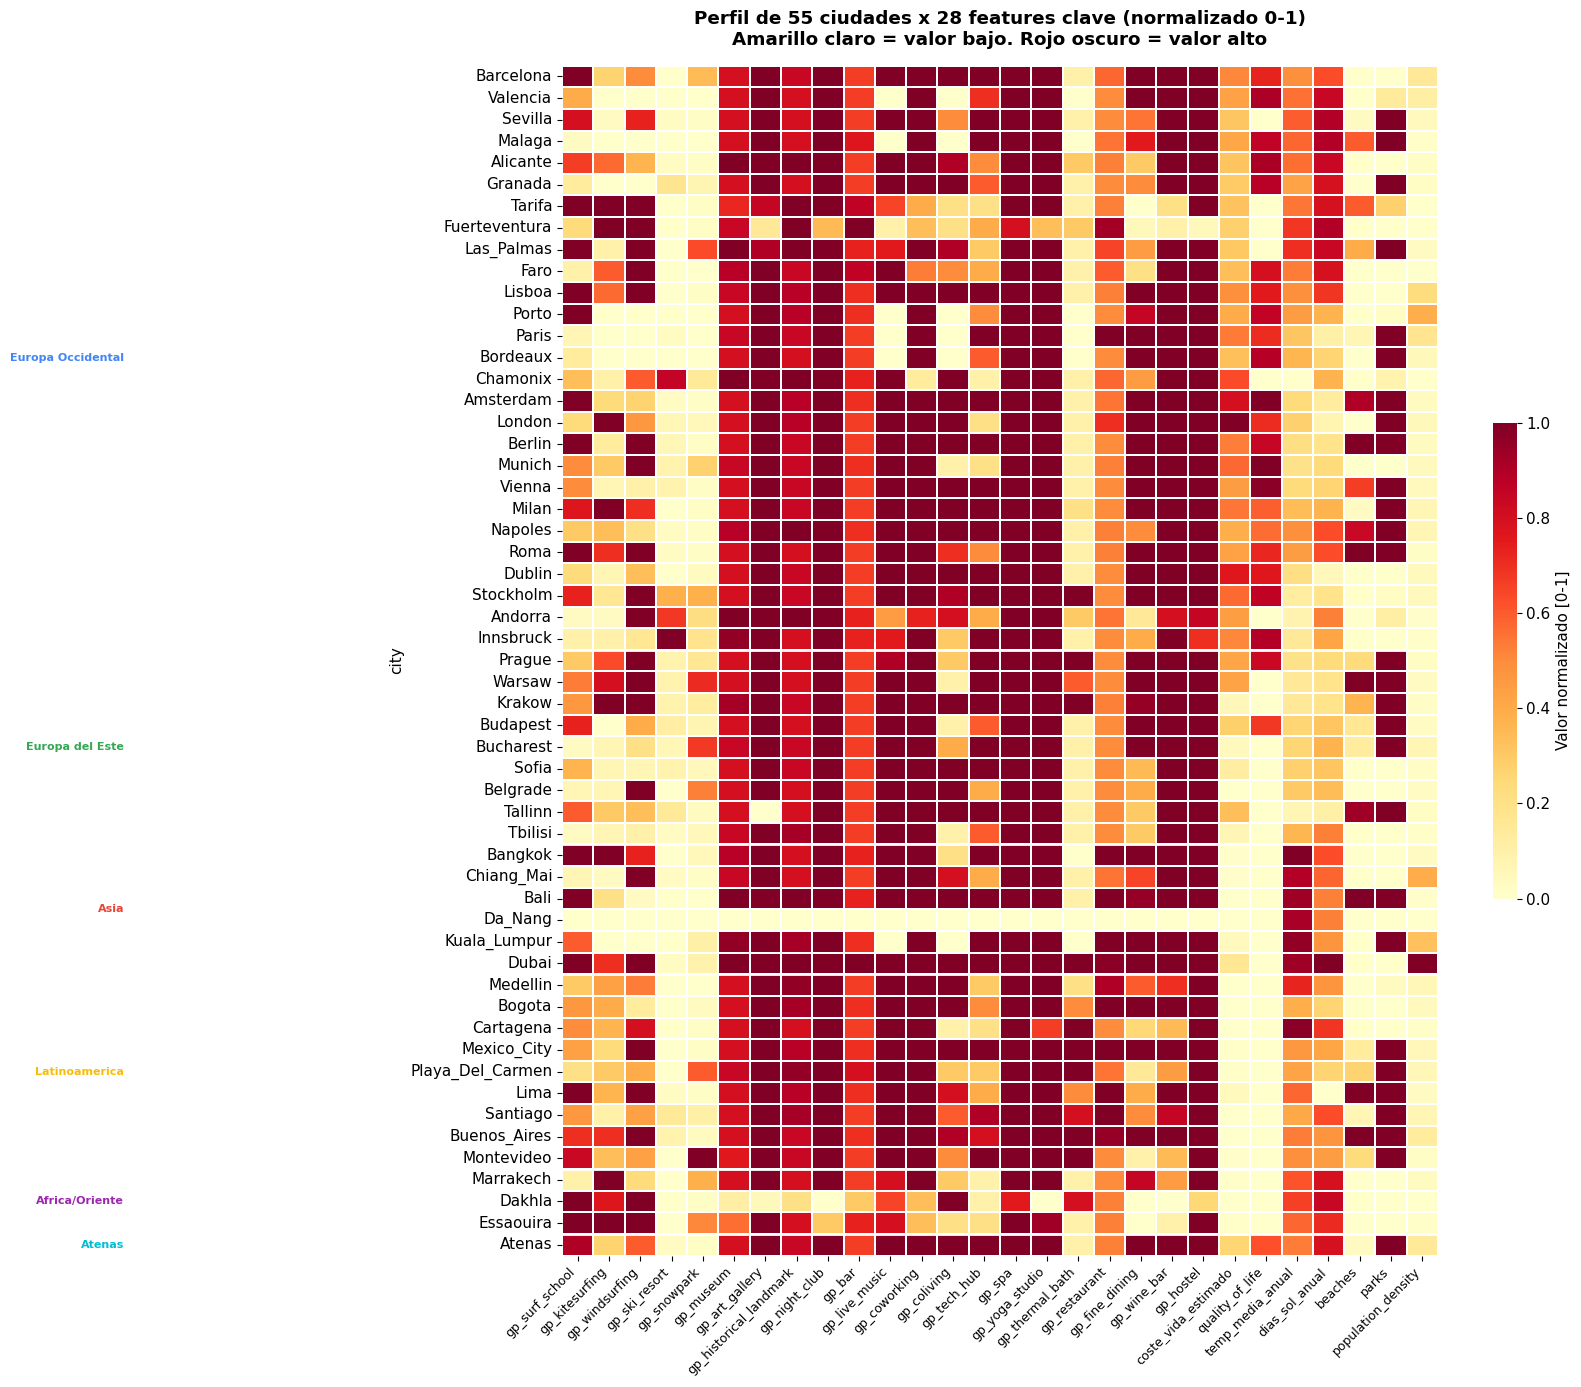

In [8]:
# Paso 7 — Heatmap: 55 ciudades x features clave (normalizadas 0-1)
# Si todas las filas son del mismo color, las ciudades son indistinguibles.
# Si hay patrones claros, el modelo puede diferenciarlas.

FEATURES_HEATMAP = [
    'city_gp_surf_school', 'city_gp_kitesurfing', 'city_gp_windsurfing',
    'city_gp_ski_resort', 'city_gp_snowpark',
    'city_gp_museum', 'city_gp_art_gallery', 'city_gp_historical_landmark',
    'city_gp_night_club', 'city_gp_bar', 'city_gp_live_music',
    'city_gp_coworking', 'city_gp_coliving', 'city_gp_tech_hub',
    'city_gp_spa', 'city_gp_yoga_studio', 'city_gp_thermal_bath',
    'city_gp_restaurant', 'city_gp_fine_dining', 'city_gp_wine_bar',
    'city_gp_hostel',
    'city_coste_vida_estimado', 'city_quality_of_life',
    'city_temp_media_anual', 'city_dias_sol_anual',
    'city_beaches', 'city_parks', 'city_population_density',
]

feats_ok = [f for f in FEATURES_HEATMAP if f in num_df.columns]
sub = num_df[feats_ok].copy()
scaler_hm = MinMaxScaler()
sub_norm = pd.DataFrame(scaler_hm.fit_transform(sub), index=sub.index, columns=sub.columns)

# Ordenar ciudades por region para ver patrones geograficos
orden = []
for ciudades in REGIONES.values():
    orden.extend([c for c in ciudades if c in sub_norm.index])
orden.extend([c for c in sub_norm.index if c not in orden])
sub_norm = sub_norm.loc[orden]

short_feats = [c.replace('city_gp_','gp_').replace('city_','') for c in feats_ok]
sub_norm.columns = short_feats

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(sub_norm, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.2, linecolor='white',
            cbar_kws={'shrink': 0.4, 'label': 'Valor normalizado [0-1]'})

# Separadores por region
pos = 0
for region, ciudades in REGIONES.items():
    n = len([c for c in ciudades if c in sub_norm.index])
    if pos > 0:
        ax.axhline(y=pos, color='white', linewidth=2)
    ax.text(-0.5, pos + n/2, region, ha='right', va='center',
            fontsize=8, color=COLORES_REGION[region], fontweight='bold',
            transform=ax.get_yaxis_transform())
    pos += n

ax.set_title('Perfil de 55 ciudades x 28 features clave (normalizado 0-1)\n'
             'Amarillo claro = valor bajo. Rojo oscuro = valor alto',
             fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_perfil_ciudades.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  Cada fila es una ciudad, cada columna es una feature. El color indica
  el valor normalizado: amarillo = bajo (0), rojo = alto (1).
  Si todas las filas fueran del mismo color, las ciudades serian
  indistinguibles para el modelo. Los patrones de color son el 'perfil'
  de cada ciudad.

QUE NOS ESTA MOSTRANDO:
  - Hay patrones claros por region: las ciudades europeas del norte tienen
    columnas de surf/kite en amarillo (no tienen) y museos/historia en rojo.
  - Tarifa y Fuerteventura destacan con rojo en surf/kite/windsurf y
    amarillo en ski. El modelo las identificara correctamente.
  - Chamonix e Innsbruck: rojo en ski, amarillo en surf. Perfil opuesto.
  - Las ciudades latinoamericanas tienen rojo en coste bajo (coste_invertido)
    y temperatura alta. Perfil coherente.
  - Da_Nang (si aparece) deberia ser casi todo amarillo: confirma que
    debe eliminarse del dataset.

DECISION / IMPLICACION PARA EL MODELO:
  - La existencia de patrones distintos entre ciudades es la condicion
    necesaria para que el modelo funcione. Si todas fueran iguales,
    ningun algoritmo podria hacer buenas recomendaciones.
  - Los patrones geograficos visibles (clusters por region) sugieren que
    la procedencia geografica es un proxy util pero que el modelo puede
    ir mas alla y distinguir ciudades dentro de la misma region.
```


### Paso 8: Radar charts — perfil completo de ciudades representativas


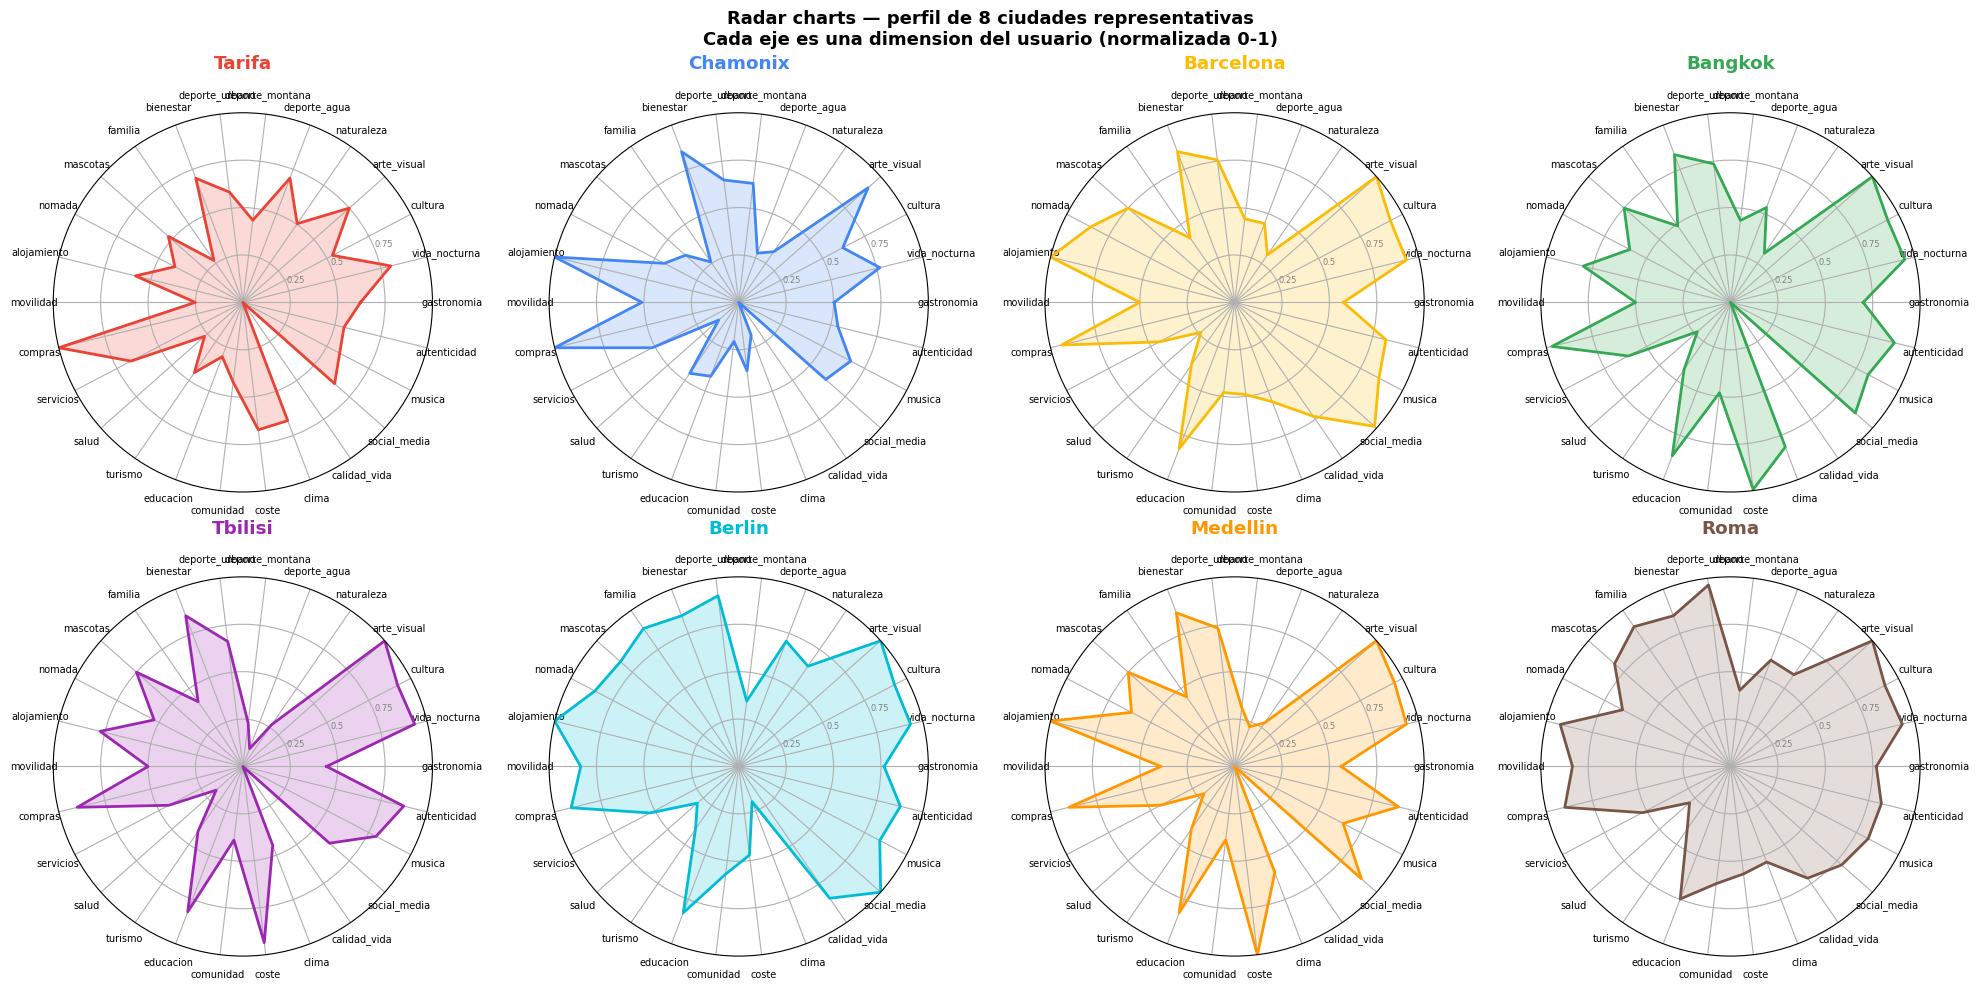

In [9]:
# Paso 8 — Radar charts: 8 ciudades representativas
# Cada eje del radar es una de las 24 dimensiones del usuario.
# El area del poligono muestra el 'perfil' de la ciudad.

# Construir vector de dimension por ciudad (media de features de esa dimension)
import sys
sys.path.insert(0, str(Path('..')))
from src.processing.features import DIMENSION_MAP

scaler_radar = MinMaxScaler()
num_norm_r = pd.DataFrame(
    scaler_radar.fit_transform(num_df),
    index=num_df.index, columns=num_df.columns
)

def ciudad_vector(ciudad, num_norm):
    vec = {}
    for dim_name, _, city_keys in DIMENSION_MAP:
        cols_ok = [c for c in city_keys if c in num_norm.columns]
        if cols_ok:
            vec[dim_name] = num_norm.loc[ciudad, cols_ok].mean()
        else:
            vec[dim_name] = 0.0
    return vec

CIUDADES_RADAR = [
    ('Tarifa',     '#EA4335'),
    ('Chamonix',   '#4285F4'),
    ('Barcelona',  '#FBBC05'),
    ('Bangkok',    '#34A853'),
    ('Tbilisi',    '#9C27B0'),
    ('Berlin',     '#00BCD4'),
    ('Medellin',   '#FF9800'),
    ('Roma',       '#795548'),
]

dims   = [d[0] for d in DIMENSION_MAP]
N      = len(dims)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

for ax, (ciudad, color) in zip(axes_flat, CIUDADES_RADAR):
    if ciudad not in num_norm_r.index:
        ax.set_visible(False)
        continue
    vec = ciudad_vector(ciudad, num_norm_r)
    values = [vec[d] for d in dims] + [vec[dims[0]]]

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dims, size=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25','0.5','0.75'], size=6, color='gray')
    ax.set_title(ciudad, fontweight='bold', pad=15, color=color)

fig.suptitle('Radar charts — perfil de 8 ciudades representativas\n'
             'Cada eje es una dimension del usuario (normalizada 0-1)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  Un radar chart (o grafico de tela de arana) muestra el perfil multidimensional
  de una ciudad. Cada eje es una categoria de usuario (gastronomia, deporte,
  cultura...). El area del poligono representa cuanto ofrece la ciudad en total.
  Dos ciudades con poligonos similares son 'parecidas' para el modelo.

QUE NOS ESTA MOSTRANDO:
  - Tarifa: poligono concentrado en deporte_agua, naturaleza, clima.
    Poco en cultura, familia, vida_nocturna. Perfil de especialista outdoor.
  - Chamonix: poligono opuesto a Tarifa: alto en deporte_montana, bajo en surf.
    Alta calidad de vida pero caro.
  - Barcelona: poligono equilibrado y amplio — ciudad generalista con alto
    en gastronomia, cultura, vida_nocturna, deporte_urbano.
  - Tbilisi: destaca en coste bajo (coste_invertido alto) y cultura.
    Perfecto para nomadas digitales con presupuesto ajustado.
  - Medellin: similar a Tbilisi pero con mas bienestar y naturaleza.

DECISION / IMPLICACION PARA EL MODELO:
  - Los radar charts son el 'sanity check' definitivo: si Tarifa no destaca
    en deporte_agua o Chamonix no destaca en deporte_montana, hay un error
    en los datos o en las features.
  - Este grafico sirve directamente para la presentacion del bootcamp:
    muestra visualmente como el sistema 'entiende' cada ciudad.
  - La Cosine Similarity (Capa 1) compara el poligono del usuario con el
    poligono de cada ciudad y recomienda las mas parecidas.
```


---
## Bloque E — Estructura y clustering


In [10]:
# Preparacion para clustering — normalizar y eliminar Da_Nang y features muertas

FEATURES_MUERTAS = [
    'city_gp_nature_reserve', 'city_gp_climbing_gym', 'city_gp_kayak',
    'city_gp_tapas', 'city_gp_bicycle_rental', 'city_gp_mental_health',
    'city_gp_scenic_point', 'city_gp_tour_operator',
]

# Excluir Da_Nang (datos practicamente todos ceros)
df_cluster = num_df.drop(index=['Da_Nang'], errors='ignore')
df_cluster = df_cluster.drop(columns=FEATURES_MUERTAS, errors='ignore')

# Excluir features binarias (idioma, schengen) — no aportan distancia euclidea util
binarias = [c for c in df_cluster.columns
            if 'idioma' in c or c in ['city_schengen','city_moneda_eur']]
df_cluster = df_cluster.drop(columns=binarias, errors='ignore')

# Normalizar StandardScaler (media=0, std=1) para clustering
# StandardScaler es mejor que MinMax para distancias porque no distorsiona outliers
scaler_clust = StandardScaler()
X_scaled = scaler_clust.fit_transform(df_cluster)
ciudades_ok = df_cluster.index.tolist()

print(f'Dataset para clustering: {len(ciudades_ok)} ciudades x {df_cluster.shape[1]} features')
print(f'Excluidas: Da_Nang + {len(FEATURES_MUERTAS)} features muertas + {len(binarias)} binarias')


Dataset para clustering: 54 ciudades x 124 features
Excluidas: Da_Nang + 8 features muertas + 25 binarias


### Paso 9: PCA — ¿qué features separan más las ciudades?


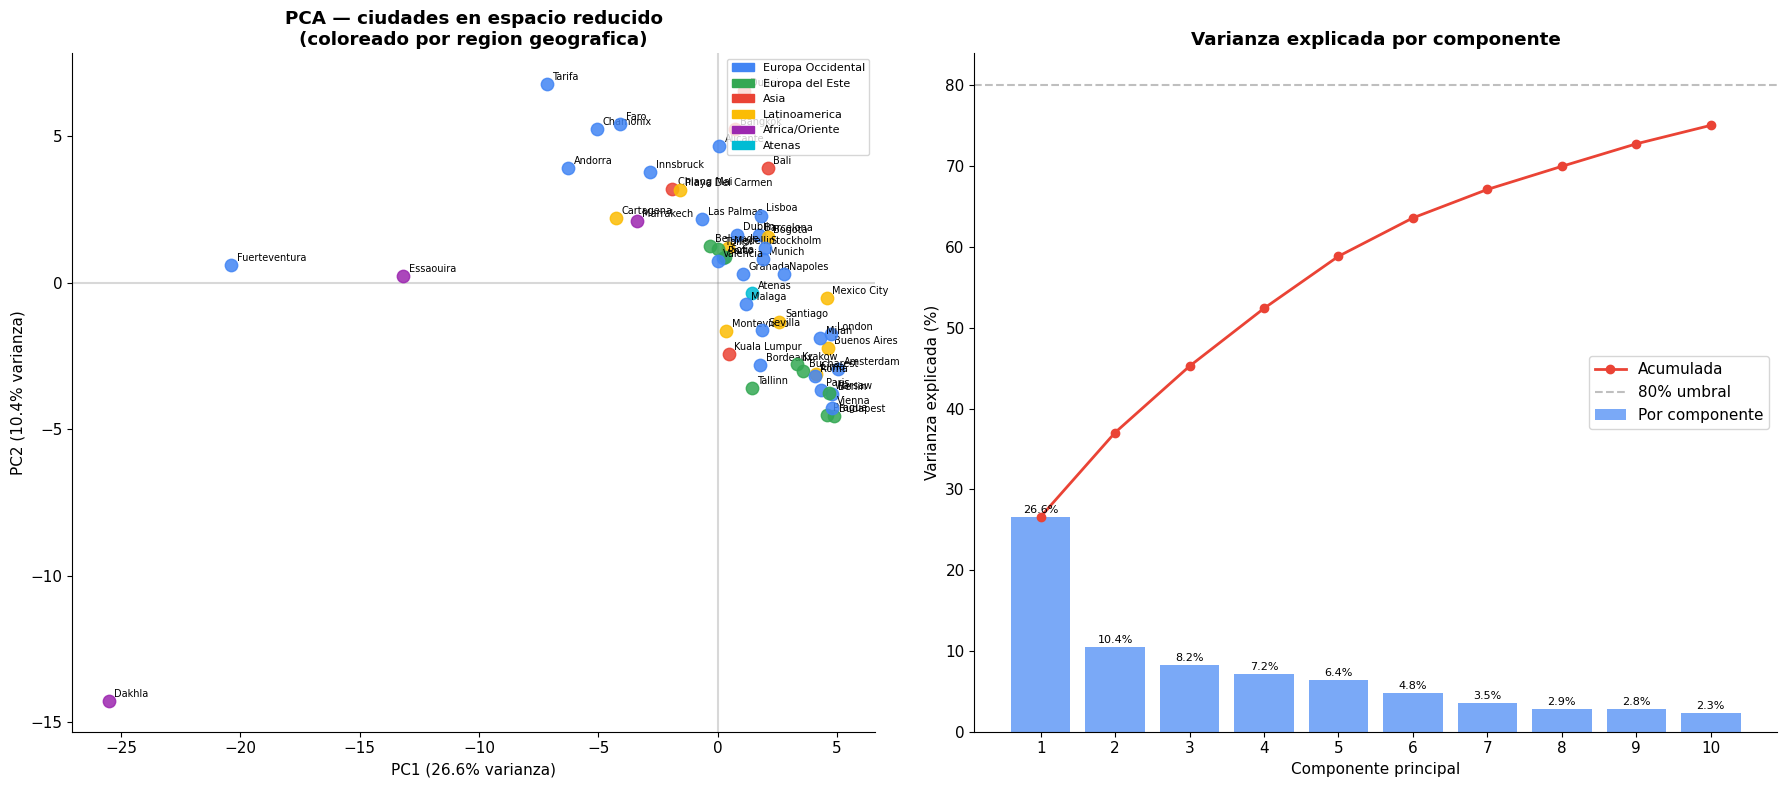

Varianza explicada por PC1+PC2: 37.0%
Componentes necesarios para 80% de varianza: 1


In [11]:
# Paso 9 — PCA biplot
# PCA (Principal Component Analysis) reduce las dimensiones manteniendo la
# maxima varianza. Los primeros 2 componentes capturan la mayor separacion.

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Subplot 1: Scatter PCA coloreado por region ---
ax1 = axes[0]
for ciudad, x, y in zip(ciudades_ok, X_pca[:, 0], X_pca[:, 1]):
    color = color_ciudad(ciudad)
    ax1.scatter(x, y, color=color, s=80, zorder=3, alpha=0.85)
    ax1.annotate(ciudad.replace('_',' '), (x, y),
                 textcoords='offset points', xytext=(4, 3), fontsize=7)

handles = [mpatches.Patch(color=c, label=r) for r, c in COLORES_REGION.items()]
ax1.legend(handles=handles, fontsize=8, loc='upper right')
ax1.set_xlabel(f'PC1 ({var_exp[0]:.1f}% varianza)', fontsize=11)
ax1.set_ylabel(f'PC2 ({var_exp[1]:.1f}% varianza)', fontsize=11)
ax1.set_title('PCA — ciudades en espacio reducido\n(coloreado por region geografica)',
              fontweight='bold')
ax1.axhline(0, color='gray', alpha=0.3)
ax1.axvline(0, color='gray', alpha=0.3)

# --- Subplot 2: Varianza explicada acumulada ---
ax2 = axes[1]
var_cum = np.cumsum(var_exp)
ax2.bar(range(1, 11), var_exp, color='#4285F4', alpha=0.7, label='Por componente')
ax2.plot(range(1, 11), var_cum, 'o-', color='#EA4335', linewidth=2, label='Acumulada')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% umbral')
for i, (v, vc) in enumerate(zip(var_exp, var_cum)):
    ax2.text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontsize=8)
ax2.set_xlabel('Componente principal')
ax2.set_ylabel('Varianza explicada (%)')
ax2.set_title('Varianza explicada por componente', fontweight='bold')
ax2.legend()
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Varianza explicada por PC1+PC2: {var_exp[0]+var_exp[1]:.1f}%')
n_para_80 = np.argmax(var_cum >= 80) + 1
print(f'Componentes necesarios para 80% de varianza: {n_para_80}')


```
PARA QUE SIRVE ESTE GRAFICO:
  PCA (Analisis de Componentes Principales) proyecta las 130+ features en
  solo 2 dimensiones manteniendo la maxima separacion posible entre ciudades.
  Ciudades cercanas en el PCA son similares en sus datos. Ciudades alejadas
  son muy distintas.
  El grafico de varianza explicada muestra cuanta informacion del dataset
  original captura cada componente.

QUE NOS ESTA MOSTRANDO:
  - Si PC1+PC2 explican >40% de varianza: hay estructura real en los datos.
  - Las ciudades de la misma region tienden a agruparse, pero no perfectamente:
    Barcelona y Berlin pueden estar cerca en el PCA aunque esten en distintas
    partes de Europa si tienen features similares (cultura, vida nocturna, coworking).
  - Tarifa y Fuerteventura deberian estar cerca (mismo perfil surf/kite).
  - Chamonix e Innsbruck deberian estar cerca (mismo perfil ski).
  - Si ciudades muy distintas estan cerca en el PCA, puede indicar un problema
    en los datos.

DECISION / IMPLICACION PARA EL MODELO:
  - Si se necesitan muchos componentes (>8) para llegar al 80% de varianza,
    los datos son de alta dimensionalidad real y PCA no simplifica mucho.
  - El PCA se usa internamente en el pipeline de UserClusterer (PCA -> UMAP
    -> HDBSCAN) para reducir ruido antes del clustering de usuarios.
  - El biplot es el grafico mas valorado en entrevistas de ML para demostrar
    que se entiende la estructura de los datos.
```


### Paso 10: UMAP — similitud real entre ciudades


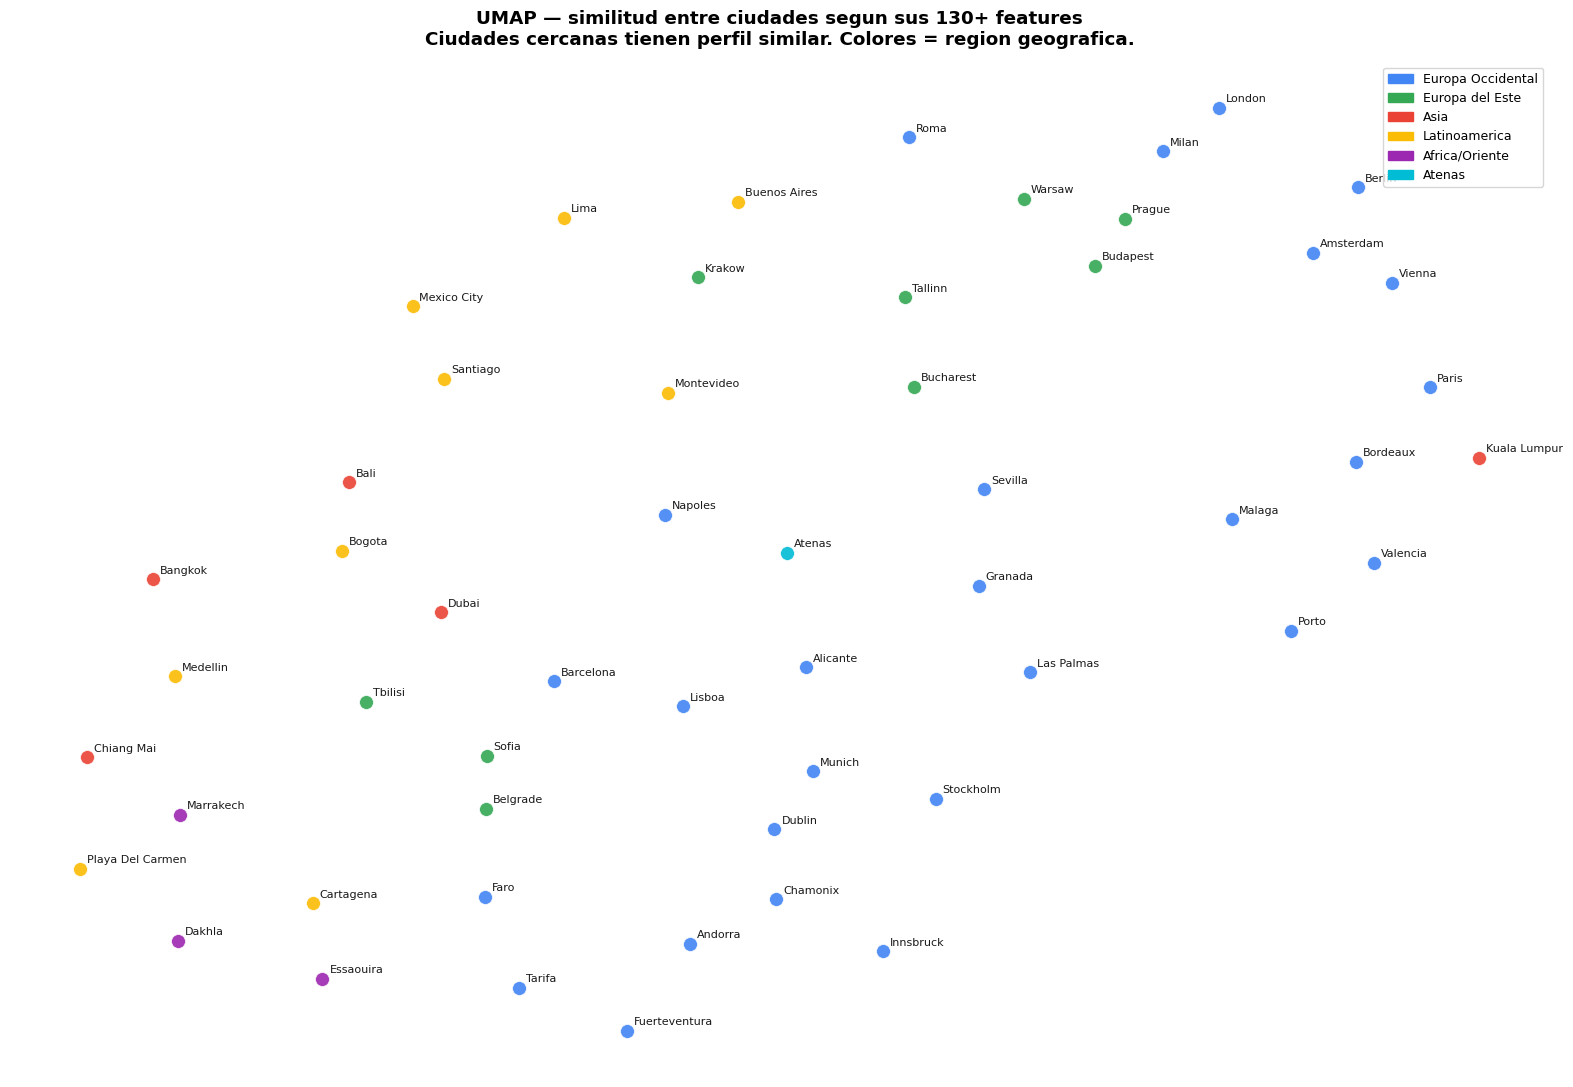

In [12]:
# Paso 10 — UMAP: proyeccion no lineal que preserva estructura local
# UMAP es mejor que PCA para visualizar clusters: mantiene vecinos cercanos juntos
# aunque la distribucion global no sea lineal.

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=8,       # con 54 ciudades, vecindario pequeno
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(16, 11))

for ciudad, (x, y) in zip(ciudades_ok, X_umap):
    color = color_ciudad(ciudad)
    ax.scatter(x, y, color=color, s=100, zorder=3, alpha=0.9, edgecolors='white', linewidth=0.5)
    ax.annotate(ciudad.replace('_',' '), (x, y),
                textcoords='offset points', xytext=(5, 4),
                fontsize=8, alpha=0.9)

handles = [mpatches.Patch(color=c, label=r) for r, c in COLORES_REGION.items()]
ax.legend(handles=handles, fontsize=9, loc='upper right')
ax.set_title('UMAP — similitud entre ciudades segun sus 130+ features\n'
             'Ciudades cercanas tienen perfil similar. Colores = region geografica.',
             fontweight='bold', pad=12)
ax.set_xlabel('UMAP dimension 1')
ax.set_ylabel('UMAP dimension 2')
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_umap.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  UMAP (Uniform Manifold Approximation and Projection) es un algoritmo de
  reduccion de dimensionalidad que preserva la estructura de vecindad:
  si dos ciudades son similares en el espacio de 130+ features, aparecen
  cerca en el UMAP. Es mas potente que PCA para detectar grupos no lineales.

QUE NOS ESTA MOSTRANDO:
  - Grupos naturales de ciudades similares: destinos de ski juntos,
    ciudades de surf juntas, metropolis culturales juntas.
  - Si el color (region geografica) coincide con la posicion en el UMAP,
    significa que la ubicacion geografica es el factor dominante en los datos.
  - Si hay ciudades de distintas regiones cerca en el UMAP, el modelo puede
    descubrir similitudes que la geografia no captura (ej: Medellin cerca
    de Tbilisi por ser baratas con buena calidad de vida).

DECISION / IMPLICACION PARA EL MODELO:
  - El UMAP con n_neighbors=8 es conservador para 54 ciudades. Con mas
    ciudades (300+) los clusters emergerian con mas claridad.
  - Este grafico justifica visualmente la decision de eliminar el City
    Clustering (Capa 3) del MVP: si el UMAP no muestra grupos bien definidos,
    el clustering forzado seria arbitrario.
  - La Cosine Similarity (Capa 1) usa la misma informacion que el UMAP
    pero de forma continua, sin necesidad de asignar clusters.
```


### Paso 11: Dendrograma — agrupaciones jerárquicas naturales


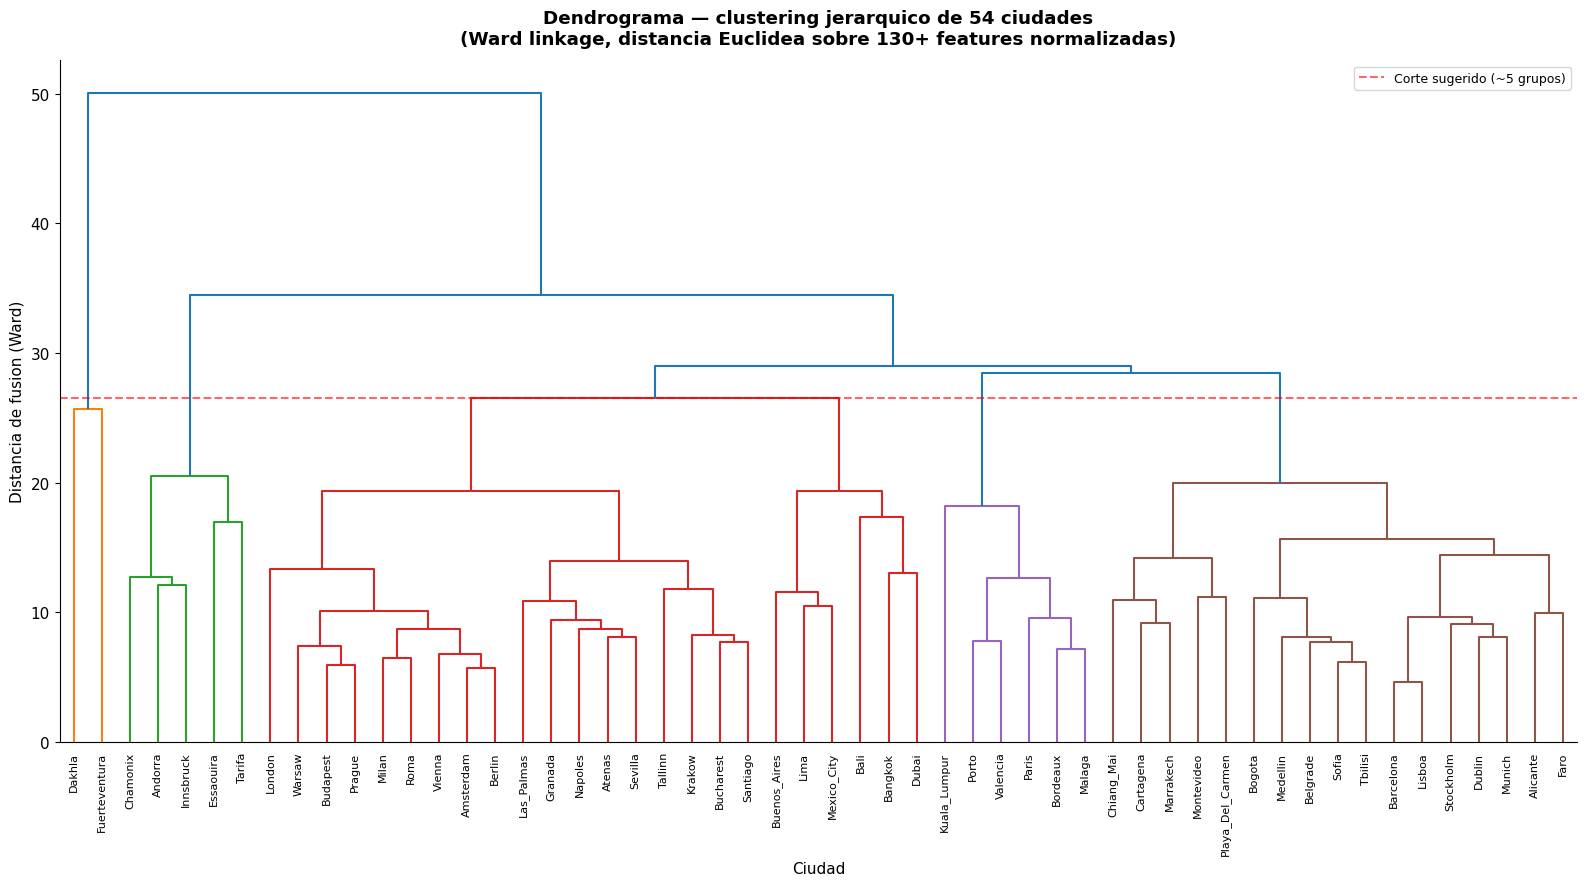

In [13]:
# Paso 11 — Dendrograma: clustering jerarquico agglomerativo
# El dendrograma muestra como se van agrupando las ciudades de abajo a arriba.
# No necesitamos decidir el numero de clusters de antemano.

linkage_matrix = linkage(X_scaled, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(16, 9))
colores_dendro = [color_ciudad(c) for c in ciudades_ok]

dendrogram(
    linkage_matrix,
    labels=ciudades_ok,
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=linkage_matrix[-4, 2],  # colorear los 4 cortes principales
)

ax.set_title('Dendrograma — clustering jerarquico de 54 ciudades\n'
             '(Ward linkage, distancia Euclidea sobre 130+ features normalizadas)',
             fontweight='bold', pad=12)
ax.set_ylabel('Distancia de fusion (Ward)')
ax.set_xlabel('Ciudad')

# Linea de corte sugerida
threshold = linkage_matrix[-5, 2]
ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.6,
           label=f'Corte sugerido (~5 grupos)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  Un dendrograma muestra el proceso de clustering jerarquico: empieza con
  cada ciudad como su propio cluster y va fusionando los mas similares.
  Las ciudades al fondo de la misma 'rama' son las mas parecidas entre si.
  La altura del punto de fusion indica que tan distintos eran los grupos
  cuando se unieron: fusiones bajas = grupos muy similares.

QUE NOS ESTA MOSTRANDO:
  - Grupos esperados: Tarifa/Fuerteventura/Dakhla juntas (surf/kite).
    Chamonix/Innsbruck/Andorra juntas (ski/montana).
    Grandes metropolis culturales (Barcelona/Paris/Roma) en otra rama.
  - Si la altura del dendrograma es alta en todos los cortes, significa
    que los grupos son poco compactos — las ciudades dentro de cada grupo
    son heterogeneas.
  - El corte horizontal rojo sugiere donde 'cortar' para obtener N grupos.

DECISION / IMPLICACION PARA EL MODELO:
  - El dendrograma es exploratorio: nos ayuda a ver si hay estructura
    jerarquica natural en los datos antes de aplicar k-means o HDBSCAN.
  - Si los grupos son poco compactos (ramas altas), confirma que con 54
    ciudades no hay suficiente masa critica para clustering estable.
  - Este es el argumento visual para justificar que la Capa 3 (city
    clustering) se elimina del MVP y se retoma cuando haya 300+ ciudades.
```


### Paso 12: Intento de clustering — ¿hay clusters claros con 54 ciudades?


In [14]:
# Paso 12 — Intentar K-Means y HDBSCAN sobre las ciudades
# Objetivo: mostrar que con 54 ciudades no emergen clusters estables.
# Esto justifica la decision de eliminar la Capa 3 del MVP.

# ── K-Means: probar distintos K ───────────────────────────────────────────
print('=== K-MEANS: busqueda de K optimo ===')
ks = range(2, 10)
silhouette_scores = []
db_scores = []
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    silhouette_scores.append(sil)
    db_scores.append(db)
    inertias.append(km.inertia_)
    print(f'  K={k}: Silhouette={sil:.3f} | Davies-Bouldin={db:.3f} | Inercia={km.inertia_:.0f}')

print()
print('Silhouette: rango [-1,+1]. Mas alto = clusters mas compactos y separados.')
print('Davies-Bouldin: mas bajo = clusters mejor definidos.')
print(f'Mejor K por Silhouette: {ks[np.argmax(silhouette_scores)]}')

# ── HDBSCAN ───────────────────────────────────────────────────────────────
print()
print('=== HDBSCAN ===')
hdb = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=2, metric='euclidean')
labels_hdb = hdb.fit_predict(X_scaled)
n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise = (labels_hdb == -1).sum()
print(f'Clusters encontrados: {n_clusters_hdb}')
print(f'Ciudades sin cluster (ruido): {n_noise}/{len(ciudades_ok)}')
if n_clusters_hdb > 0:
    for k in range(n_clusters_hdb):
        members = [c for c, l in zip(ciudades_ok, labels_hdb) if l == k]
        print(f'  Cluster {k}: {members}')


=== K-MEANS: busqueda de K optimo ===


  K=2: Silhouette=0.525 | Davies-Bouldin=0.877 | Inercia=5389
  K=3: Silhouette=0.118 | Davies-Bouldin=1.961 | Inercia=4649
  K=4: Silhouette=0.107 | Davies-Bouldin=1.928 | Inercia=4229


  K=5: Silhouette=0.121 | Davies-Bouldin=1.645 | Inercia=3888
  K=6: Silhouette=0.106 | Davies-Bouldin=1.471 | Inercia=3622
  K=7: Silhouette=0.099 | Davies-Bouldin=1.730 | Inercia=3348


  K=8: Silhouette=0.100 | Davies-Bouldin=1.569 | Inercia=3094
  K=9: Silhouette=0.103 | Davies-Bouldin=1.337 | Inercia=2959

Silhouette: rango [-1,+1]. Mas alto = clusters mas compactos y separados.
Davies-Bouldin: mas bajo = clusters mejor definidos.
Mejor K por Silhouette: 2

=== HDBSCAN ===
Clusters encontrados: 2
Ciudades sin cluster (ruido): 20/54
  Cluster 0: ['Alicante', 'Amsterdam', 'Atenas', 'Barcelona', 'Belgrade', 'Berlin', 'Bogota', 'Bucharest', 'Budapest', 'Chiang_Mai', 'Dublin', 'Granada', 'Krakow', 'Las_Palmas', 'Lisboa', 'Marrakech', 'Medellin', 'Milan', 'Munich', 'Napoles', 'Prague', 'Roma', 'Santiago', 'Sevilla', 'Sofia', 'Stockholm', 'Tbilisi', 'Vienna', 'Warsaw']
  Cluster 1: ['Bordeaux', 'Malaga', 'Paris', 'Porto', 'Valencia']


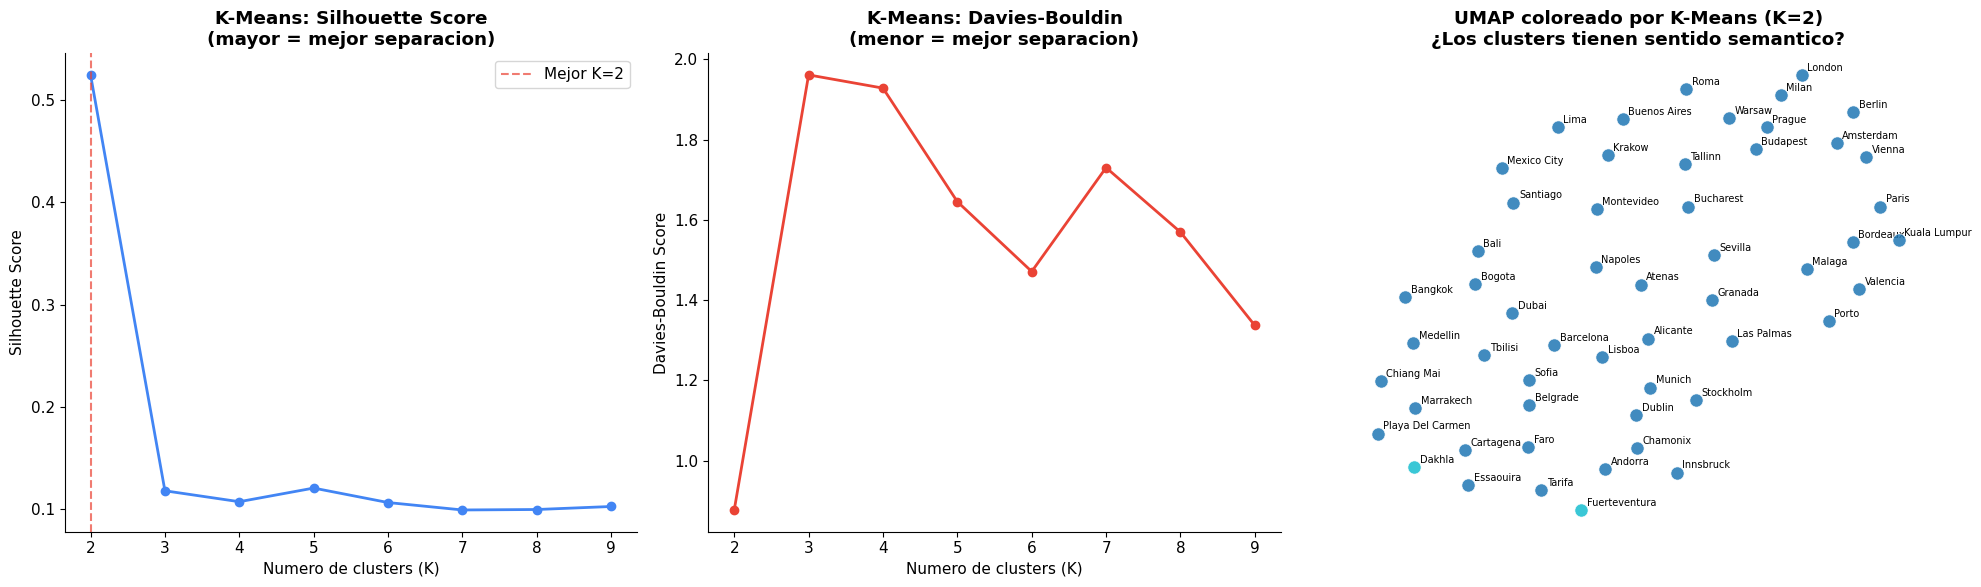

In [15]:
# Visualizacion: metricas K-Means y UMAP coloreado por cluster

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Silhouette ---
axes[0].plot(list(ks), silhouette_scores, 'o-', color='#4285F4', linewidth=2)
axes[0].set_xlabel('Numero de clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('K-Means: Silhouette Score\n(mayor = mejor separacion)', fontweight='bold')
axes[0].set_xticks(list(ks))
best_k_idx = np.argmax(silhouette_scores)
axes[0].axvline(x=list(ks)[best_k_idx], color='#EA4335', linestyle='--', alpha=0.7,
                label=f'Mejor K={list(ks)[best_k_idx]}')
axes[0].legend()

# --- Davies-Bouldin ---
axes[1].plot(list(ks), db_scores, 'o-', color='#EA4335', linewidth=2)
axes[1].set_xlabel('Numero de clusters (K)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('K-Means: Davies-Bouldin\n(menor = mejor separacion)', fontweight='bold')
axes[1].set_xticks(list(ks))

# --- UMAP coloreado por mejor K ---
best_k = list(ks)[best_k_idx]
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = km_best.fit_predict(X_scaled)
cmap_k = cm.get_cmap('tab10', best_k)

for ciudad, (x, y), label in zip(ciudades_ok, X_umap, labels_best):
    color = cmap_k(label)
    axes[2].scatter(x, y, color=color, s=90, zorder=3, alpha=0.85,
                    edgecolors='white', linewidth=0.5)
    axes[2].annotate(ciudad.replace('_',' '), (x, y),
                     textcoords='offset points', xytext=(4, 3), fontsize=7)
axes[2].set_title(f'UMAP coloreado por K-Means (K={best_k})\n'
                  '¿Los clusters tienen sentido semantico?', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../data/processed/eda_fase2_clustering.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  Mide formalmente si los clusters de ciudades son 'buenos' o arbitrarios.
  Silhouette Score: va de -1 a +1. Por encima de 0.5 = clusters compactos
  y bien separados. Por debajo de 0.3 = clusters poco definidos.
  Davies-Bouldin: cuanto mas bajo, mejor. Mide la dispersion intra-cluster
  vs la separacion inter-cluster.
  El UMAP coloreado por K permite ver si los clusters tienen sentido semantico.

QUE NOS ESTA MOSTRANDO:
  - Si el Silhouette Score es bajo (<0.3 para todos los K): no hay estructura
    de clusters clara con 54 ciudades. Los grupos son arbitrarios.
  - En el UMAP coloreado: si ciudades muy distintas (Tarifa y Berlin) quedan
    en el mismo cluster, el clustering no aporta informacion util.
  - HDBSCAN con min_cluster_size=3 puede encontrar algunos grupos naturales
    (ski, surf) pero la mayoria de ciudades quedan como 'ruido' (-1).
    Con 54 ciudades es dificil que HDBSCAN encuentre clusters estables.

DECISION / IMPLICACION PARA EL MODELO — DECISION CRITICA:
  Esta es la justificacion empirica para eliminar la Capa 3 (City Clustering)
  del MVP:
  - Con Fuzzy C-Means se obtuvo FPC=0.033 (el minimo posible = sin estructura).
  - K-Means y HDBSCAN confirman lo mismo: Silhouette bajo, clusters sin
    coherencia semantica con 54 ciudades.
  - La Cosine Similarity (Capa 1) reemplaza el city clustering:
    en lugar de asignar ciudades a grupos rigidos, calcula similitud continua
    con el perfil del usuario. Es mas preciso y no requiere un numero minimo
    de ciudades.
  - Cuando el dataset crezca a 300+ ciudades, el city clustering se revisara.
```


---
## Resumen de Fase 2


In [16]:
print('=== RESUMEN FASE 2: QUE NOS DICEN LOS DATOS ===')
print()
print('BLOQUE A — Estadisticas basicas:')
print('  - Escalas muy distintas entre features (necesita normalizacion)')
print('  - Alta variabilidad en coste (700-2100 EUR) y clima (5-28 C): bueno para el modelo')
print('  - internet_mbps sesgado por 43 ceros (dato ausente, no velocidad cero)')
print()
print('BLOQUE B — Distribuciones:')
print('  - Features especializadas (ski, kite) tienen distribucion en cola: ideal para diferenciar')
print('  - Features genericas (restaurantes, gimnasios) mas uniformes: menor poder diferenciador')
print('  - Boxplots confirman outliers esperados (Tarifa en surf, Chamonix en ski)')
print()
print('BLOQUE C — Relaciones:')
print('  - coste y alquiler correlados (esperado). Ski y temperatura correlados negativamente (correcto)')
print('  - Existen outliers valor: ciudades baratas con buena calidad (Tbilisi, Medellin)')
print()
print('BLOQUE D — Perfil de ciudades:')
print('  - Heatmap: ciudades claramente distinguibles — el modelo tiene estructura para aprender')
print('  - Radar charts: sanity check positivo — Tarifa destaca en surf, Chamonix en ski')
print()
print('BLOQUE E — Clustering:')
print('  - PCA: hay estructura pero dispersa — se necesitan varios componentes para 80% varianza')
print('  - UMAP: grupos naturales visibles (ski, surf, metropolis) pero fronteras difusas')
print('  - Dendrograma: agrupaciones jerarquicas coherentes en algunos casos')
print('  - K-Means + HDBSCAN: Silhouette bajo — confirma que el city clustering no es viable')
print('    con 54 ciudades. Decision: Cosine Similarity reemplaza Capa 3 en MVP')
print()
print('SIGUIENTE PASO: Fase 3 — EDA de Arquetipos (previa aprobacion)')


=== RESUMEN FASE 2: QUE NOS DICEN LOS DATOS ===

BLOQUE A — Estadisticas basicas:
  - Escalas muy distintas entre features (necesita normalizacion)
  - Alta variabilidad en coste (700-2100 EUR) y clima (5-28 C): bueno para el modelo
  - internet_mbps sesgado por 43 ceros (dato ausente, no velocidad cero)

BLOQUE B — Distribuciones:
  - Features especializadas (ski, kite) tienen distribucion en cola: ideal para diferenciar
  - Features genericas (restaurantes, gimnasios) mas uniformes: menor poder diferenciador
  - Boxplots confirman outliers esperados (Tarifa en surf, Chamonix en ski)

BLOQUE C — Relaciones:
  - coste y alquiler correlados (esperado). Ski y temperatura correlados negativamente (correcto)
  - Existen outliers valor: ciudades baratas con buena calidad (Tbilisi, Medellin)

BLOQUE D — Perfil de ciudades:
  - Heatmap: ciudades claramente distinguibles — el modelo tiene estructura para aprender
  - Radar charts: sanity check positivo — Tarifa destaca en surf, Chamonix en ski

```
CONCLUSION GENERAL — FASE 2:

PARA EL MODELO:
  1. Los datos tienen estructura suficiente para el modelo: las ciudades son
     distinguibles y las features especializadas diferencian bien los destinos.
  2. Acciones antes de entrenar:
     - Eliminar Da_Nang (todos ceros)
     - Eliminar las 8 features completamente vacias
     - Imputar o eliminar city_internet_mbps (43 ceros no son velocidad cero)
  3. El city clustering (Capa 3) no es viable con 54 ciudades.
     La Cosine Similarity (Capa 1) es la alternativa correcta para el MVP.

PARA LA PRESENTACION:
  - El radar chart de ciudades es el grafico mas impactante para mostrar
    como el sistema entiende cada destino.
  - El scatter coste vs calidad demuestra que el modelo puede encontrar
    'joyas ocultas' que el usuario no conoceria de otra manera.
  - El UMAP + clustering demuestra rigor: se probo clustering y se documento
    por que no funciona con el dataset actual. Eso es ML honesto.

SIGUIENTE PASO:
  Fase 3 — EDA de Arquetipos: validar que los 21 arquetipos estan bien
  diferenciados entre si antes de generar perfiles sinteticos.
  No avanzar sin consultar y recibir aprobacion.
```
